
# CognIA — Notebook experto de resultados, trazabilidad y análisis ultra detallado de los 30 champions finales

Este notebook consolida la **trazabilidad metodológica** y el **análisis cuantitativo exhaustivo** de la línea final activa de modelos de CognIA en la rama `development`, con foco principal en:

1. **los 30 modelos finales activos/champions** (5 dominios × 6 modos),
2. **sus métricas completas**,
3. **sus parámetros operativos y de activación**,
4. **las decisiones que se tomaron a lo largo del tiempo**,
5. **los riesgos/caveats reales** que deben acompañar cualquier interpretación.

---

## Fuentes de verdad usadas para este notebook

### Freeze operativo / champions finales
- `data/hybrid_operational_freeze_v1/tables/hybrid_operational_final_champions.csv`

### Activación final 30/30 y metadata operativa
- `data/hybrid_active_modes_freeze_v1/tables/hybrid_active_models_30_modes.csv`
- `data/hybrid_active_modes_freeze_v1/tables/hybrid_active_modes_summary.csv`

### Trazabilidad metodológica y narrativa de decisiones
- `docs/model_registry_and_inference.md`
- `docs/traceability_map.md`
- `AGENTS.md`
- `docs/HANDOFF.md`

### Referencia histórica previa (solo para contraste, no para reemplazar la fuente actual)
- `reports/final_closure/final_model_metrics_compact.csv`

---

## Enfoque interpretativo

Este notebook **no** interpreta estos modelos como diagnóstico automático. Todo el análisis se mantiene en el marco documentado del repo:

- *screening / apoyo profesional*,
- *entorno simulado*,
- *con caveats explícitos cuando aplica*,
- *sin ocultar limitaciones estructurales*.

La idea es que este documento sirva como **pieza de auditoría técnica**, **resumen experto para tesis** y **base de discusión para decisiones de producto/runtime**.


In [16]:

import io
import math
import textwrap
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:.4f}" if isinstance(x, float) else str(x))

FINAL_CHAMPIONS_CSV = '''domain,mode,source_campaign,model_family,feature_set_id,calibration,threshold_policy,threshold,precision,recall,specificity,balanced_accuracy,f1,roc_auc,pr_auc,brier,quality_label,overfit_gap_train_val_ba,final_class
adhd,caregiver_1_3,rebuild_v2,rf,engineered_full,isotonic,default_0_5,0.5,0.6212121212121212,0.8723404255319149,0.8704663212435233,0.8714033733877191,0.7256637168141593,0.9276402822180576,0.6319179403335605,0.0868278728044155,malo,0.0192095689560136,HOLD_FOR_LIMITATION
adhd,caregiver_2_3,rebuild_v2,rf,engineered_compact,isotonic,default_0_5,0.5,0.7017543859649122,0.851063829787234,0.911917098445596,0.881490464116415,0.7692307692307693,0.9492613824275162,0.7044217957677258,0.072567246649348,malo,0.011593723587991,HOLD_FOR_LIMITATION
adhd,caregiver_full,rebuild_v2,rf,engineered_compact,isotonic,recall_constrained,0.4049999999999999,0.7403846153846154,0.8191489361702128,0.9300518134715026,0.8746003748208577,0.7777777777777778,0.9506394002866276,0.7118788252075036,0.0687218130961477,malo,0.0602561275860801,HOLD_FOR_LIMITATION
adhd,psychologist_1_3,rebuild_v2,rf,engineered_compact,isotonic,balanced,0.18,0.6148148148148148,0.8829787234042553,0.8652849740932642,0.8741318487487597,0.7248908296943232,0.9259453202513506,0.6375451264670481,0.0841732751976726,malo,0.0360948811229926,HOLD_FOR_LIMITATION
adhd,psychologist_2_3,rebuild_v2,rf,engineered_pruned,isotonic,precision_min_recall,0.5049999999999999,0.7289719626168224,0.8297872340425532,0.9248704663212436,0.8773288501818983,0.7761194029850746,0.9539604233270864,0.7337389775224177,0.0680043361765456,malo,0.0304817550435452,HOLD_FOR_LIMITATION
adhd,psychologist_full,rebuild_v2,rf,engineered_full,isotonic,precision_min_recall,0.5049999999999999,0.9294117647058824,0.8404255319148937,0.9844559585492229,0.9124407452320582,0.88268156424581,0.9892652408775218,0.9271313857162288,0.0302329344052168,muy_bueno,0.0159574468085107,ROBUST_PRIMARY
anxiety,caregiver_1_3,rebuild_v2,rf,engineered_full,isotonic,recall_constrained,0.3199999999999999,0.8875,0.8255813953488372,0.9771573604060914,0.9013693778774644,0.8554216867469879,0.9767441860465116,0.9266917820093952,0.0368358394115982,muy_bueno,0.0435898949356627,ROBUST_PRIMARY
anxiety,caregiver_2_3,rebuild_v2,rf,compact_subset,isotonic,balanced,0.3349999999999999,0.8735632183908046,0.8837209302325582,0.9720812182741116,0.9279010742533348,0.8786127167630058,0.9918840750796836,0.9524808419049928,0.0306755822953721,bueno,0.0561326879943335,ROBUST_PRIMARY
anxiety,caregiver_full,rebuild_v2,rf,precision_oriented_subset,isotonic,balanced,0.295,0.9166666666666666,0.8953488372093024,0.9822335025380712,0.9387911698736868,0.9058823529411764,0.9911462637232912,0.9465380549682876,0.0274435048754308,muy_bueno,0.0466887026325109,ROBUST_PRIMARY
anxiety,psychologist_1_3,rebuild_v2,rf,engineered_full,isotonic,precision_min_recall,0.61,0.953846153846154,0.7209302325581395,0.9923857868020304,0.856658009680085,0.8211920529801324,0.9836058316609608,0.9167286511795306,0.0355709159204354,aceptable,0.0309388895447212,PRIMARY_WITH_CAVEAT
anxiety,psychologist_2_3,rebuild_v2,rf,precision_oriented_subset,isotonic,balanced,0.2299999999999999,0.9058823529411764,0.8953488372093024,0.9796954314720812,0.937522134340692,0.9005847953216374,0.9898182032817848,0.930287612715468,0.0302180148379456,muy_bueno,0.0458426789438476,ROBUST_PRIMARY
anxiety,psychologist_full,rebuild_v2,rf,precision_oriented_subset,isotonic,default_0_5,0.5,0.9156626506024096,0.8837209302325582,0.9822335025380712,0.9329772163853146,0.8994082840236687,0.9911610199504192,0.9442183163908962,0.026760853373639,muy_bueno,0.0466887026325109,ROBUST_PRIMARY
conduct,caregiver_1_3,rebuild_v2,rf,precision_oriented_subset,none,recall_constrained,0.59,0.9019607843137256,0.8625,0.953125,0.9078125,0.8817891373801917,0.97841796875,0.9500801871541836,0.0563854385479201,bueno,0.0696280150252286,ROBUST_PRIMARY
conduct,caregiver_2_3,rebuild_v2,rf,engineered_compact,isotonic,recall_constrained,0.5049999999999999,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0012744324646449,muy_bueno,0.0047022864868042,SUSPECT_EASY_DATASET_NEEDS_CAUTION
conduct,caregiver_full,rebuild_v2,rf,engineered_compact,isotonic,precision_min_recall,0.5049999999999999,1.0,0.99375,1.0,0.996875,0.9968652037617556,1.0,1.0,0.0013267998081757,muy_bueno,0.0047022864868042,SUSPECT_EASY_DATASET_NEEDS_CAUTION
conduct,psychologist_1_3,rebuild_v2,rf,compact_subset,sigmoid,recall_constrained,0.6449999999999999,0.9090909090909092,0.8125,0.959375,0.8859375,0.858085808580858,0.97728515625,0.9542627941351364,0.0585440516294588,aceptable,0.0916305926930246,PRIMARY_WITH_CAVEAT
conduct,psychologist_2_3,rebuild_v2,rf,engineered_compact,isotonic,recall_constrained,0.5049999999999999,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0010954785521607,muy_bueno,0.0047022864868042,SUSPECT_EASY_DATASET_NEEDS_CAUTION
conduct,psychologist_full,rebuild_v2,rf,engineered_compact,isotonic,recall_constrained,0.5049999999999999,1.0,0.99375,1.0,0.996875,0.9968652037617556,1.0,1.0,0.001248309268289,muy_bueno,0.0047022864868042,SUSPECT_EASY_DATASET_NEEDS_CAUTION
depression,caregiver_1_3,rebuild_v2,rf,precision_oriented_subset,none,recall_constrained,0.5299999999999999,0.8059701492537313,0.6585365853658537,0.9673366834170856,0.8129366343914696,0.7248322147651006,0.958282264983454,0.764765007527117,0.0600670985657974,malo,0.1235015803079284,HOLD_FOR_LIMITATION
depression,caregiver_2_3,rebuild_v2,rf,full_eligible,isotonic,recall_constrained,0.2149999999999999,0.8313253012048193,0.8414634146341463,0.964824120603015,0.9031437676185808,0.8363636363636363,0.9573630346856232,0.8434143874736915,0.0454553863622029,malo,0.034395975558317,HOLD_FOR_LIMITATION
depression,caregiver_full,boosted_v3,catboost,full_eligible,none,default_0_5,0.5,0.8409090909090909,0.9487179487179488,0.965174129353234,0.9569460390355912,0.891566265060241,0.9909108304630694,0.9434742112852106,0.0293666393254193,bueno,0.0337226213696777,ROBUST_PRIMARY
depression,psychologist_1_3,rebuild_v2,rf,stability_pruned_subset,isotonic,default_0_5,0.5,0.7974683544303798,0.7682926829268293,0.9597989949748744,0.8640458389508519,0.782608695652174,0.9483852187768108,0.7681311253035743,0.0565304346753685,malo,0.1146533320982389,HOLD_FOR_LIMITATION
depression,psychologist_2_3,rebuild_v2,rf,full_eligible,isotonic,recall_constrained,0.5049999999999999,0.8271604938271605,0.8170731707317073,0.964824120603015,0.8909486456673612,0.8220858895705522,0.9556777791396004,0.8330408560571644,0.0479028069363223,malo,0.0778349888653642,HOLD_FOR_LIMITATION
depression,psychologist_full,boosted_v3,hgb,full_eligible,sigmoid,balanced,0.4199999999999999,0.8690476190476191,0.935897435897436,0.972636815920398,0.9542671259089168,0.9012345679012346,0.9923140706722796,0.9533076719585644,0.0253330721238639,bueno,0.0294736032291214,ROBUST_PRIMARY
elimination,caregiver_1_3,boosted_v3,extra_trees,boosted_eng_full,none,balanced,0.4399999999999999,0.8679245283018868,0.9019607843137256,0.9836829836829836,0.9428218839983546,0.8846153846153846,0.9967777320718496,0.9700376570280697,0.0204136197916666,bueno,0.0028735632183908,ROBUST_PRIMARY
elimination,caregiver_2_3,rebuild_v2,rf,engineered_compact,isotonic,balanced,0.2049999999999999,0.925925925925926,0.9615384615384616,0.9906542056074766,0.9760963335729692,0.9433962264150944,0.9970794392523366,0.955947602524266,0.010039232809337,muy_bueno,0.0100053987977185,ROBUST_PRIMARY
elimination,caregiver_full,rebuild_v2,rf,engineered_compact,isotonic,precision_min_recall,0.5049999999999999,0.9615384615384616,0.9615384615384616,0.9953271028037384,0.9784327821711,0.9615384615384616,0.997214234363767,0.9582613967229352,0.0081337265474628,muy_bueno,0.0384615384615384,ROBUST_PRIMARY
elimination,psychologist_1_3,boosted_v3,extra_trees,boosted_eng_full,none,balanced,0.4299999999999999,0.9019607843137256,0.9019607843137256,0.9883449883449884,0.9451528863293568,0.9019607843137256,0.9965720553955848,0.9724347146967124,0.0210442838541666,muy_bueno,0.0028735632183908,ROBUST_PRIMARY
elimination,psychologist_2_3,rebuild_v2,rf,engineered_pruned,isotonic,precision_min_recall,0.5049999999999999,0.9615384615384616,0.9615384615384616,0.9953271028037384,0.9784327821711,0.9615384615384616,0.997191768511862,0.957704540598432,0.0082233824203011,muy_bueno,0.0384615384615384,ROBUST_PRIMARY
elimination,psychologist_full,rebuild_v2,rf,engineered_compact,isotonic,precision_min_recall,0.5049999999999999,0.9433962264150944,0.9615384615384616,0.9929906542056076,0.9772645578720344,0.9523809523809524,0.998090402588066,0.9734743104312084,0.009137193084548,muy_bueno,0.0300143781452193,ROBUST_PRIMARY
'''
ACTIVE_MODELS_CSV = '''domain,mode,role,active_model_required,active_model_id,source_line,source_campaign,model_family,feature_set_id,config_id,calibration,threshold_policy,threshold,seed,n_features,precision,recall,specificity,balanced_accuracy,f1,roc_auc,pr_auc,brier,final_operational_class,overfit_flag,generalization_flag,dataset_ease_flag,confidence_pct,confidence_band,operational_caveat,recommended_for_default_use,notes
adhd,caregiver_1_3,caregiver,yes,adhd__caregiver_1_3__rebuild_v2__rf__engineered_full,hybrid_no_external_scores_rebuild_v2,rebuild_v2,rf,engineered_full,rf_regularized,isotonic,default_0_5,0.5,20261119,58,0.6212121212121212,0.8723404255319149,0.8704663212435233,0.8714033733877191,0.7256637168141593,0.9276402822180576,0.6319179403335605,0.0868278728044155,ACTIVE_LIMITED_USE,no,yes,no,34.3,limited,limited reliability; escalate to richer mode; low precision; short mode fragile,no,clean_universe_no_external_scores
adhd,caregiver_2_3,caregiver,yes,adhd__caregiver_2_3__rebuild_v2__rf__engineered_compact,hybrid_no_external_scores_rebuild_v2,rebuild_v2,rf,engineered_compact,rf_regularized,isotonic,default_0_5,0.5,20261101,43,0.7017543859649122,0.851063829787234,0.911917098445596,0.881490464116415,0.7692307692307693,0.9492613824275162,0.7044217957677258,0.072567246649348,ACTIVE_LIMITED_USE,no,yes,no,41.8,limited,limited reliability; escalate to richer mode; low precision,no,clean_universe_no_external_scores
adhd,caregiver_full,caregiver,yes,adhd__caregiver_full__rebuild_v2__rf__engineered_compact,hybrid_no_external_scores_rebuild_v2,rebuild_v2,rf,engineered_compact,rf_balanced_subsample,isotonic,recall_constrained,0.4049999999999999,20261119,53,0.7403846153846154,0.8191489361702128,0.9300518134715026,0.8746003748208577,0.7777777777777778,0.9506394002866276,0.7118788252075036,0.0687218130961477,ACTIVE_LIMITED_USE,no,yes,no,42.7,limited,limited reliability; escalate to richer mode; low precision,no,clean_universe_no_external_scores
adhd,psychologist_1_3,psychologist,yes,adhd__psychologist_1_3__rebuild_v2__rf__engineered_compact,hybrid_no_external_scores_rebuild_v2,rebuild_v2,rf,engineered_compact,rf_balanced_subsample,isotonic,balanced,0.18,20261101,30,0.6148148148148148,0.8829787234042553,0.8652849740932642,0.8741318487487597,0.7248908296943232,0.9259453202513506,0.6375451264670481,0.0841732751976726,ACTIVE_LIMITED_USE,no,yes,no,34.9,limited,limited reliability; escalate to richer mode; low precision; short mode fragile,no,clean_universe_no_external_scores
adhd,psychologist_2_3,psychologist,yes,adhd__psychologist_2_3__rebuild_v2__rf__engineered_pruned,hybrid_no_external_scores_rebuild_v2,rebuild_v2,rf,engineered_pruned,rf_regularized,isotonic,precision_min_recall,0.5049999999999999,20261101,70,0.7289719626168224,0.8297872340425532,0.9248704663212436,0.8773288501818983,0.7761194029850746,0.9539604233270864,0.7337389775224177,0.0680043361765456,ACTIVE_LIMITED_USE,no,yes,no,43.8,limited,limited reliability; escalate to richer mode; low precision,no,clean_universe_no_external_scores
adhd,psychologist_full,psychologist,yes,adhd__psychologist_full__rebuild_v2__rf__engineered_full,hybrid_no_external_scores_rebuild_v2,rebuild_v2,rf,engineered_full,rf_precision_push,isotonic,precision_min_recall,0.5049999999999999,20261101,161,0.9294117647058824,0.8404255319148937,0.9844559585492229,0.9124407452320582,0.88268156424581,0.9892652408775218,0.9271313857162288,0.0302329344052168,ACTIVE_HIGH_CONFIDENCE,no,yes,no,91.7,high,none,yes,clean_universe_no_external_scores
anxiety,caregiver_1_3,caregiver,yes,anxiety__caregiver_1_3__rebuild_v2__rf__engineered_full,hybrid_no_external_scores_rebuild_v2,rebuild_v2,rf,engineered_full,rf_pos_weight_mid,isotonic,recall_constrained,0.3199999999999999,20261101,58,0.8875,0.8255813953488372,0.9771573604060914,0.9013693778774644,0.8554216867469879,0.9767441860465116,0.9266917820093952,0.0368358394115982,ACTIVE_HIGH_CONFIDENCE,no,yes,no,88.5,high,none,yes,clean_universe_no_external_scores
anxiety,caregiver_2_3,caregiver,yes,anxiety__caregiver_2_3__rebuild_v2__rf__compact_subset,hybrid_no_external_scores_rebuild_v2,rebuild_v2,rf,compact_subset,rf_pos_weight_mid,isotonic,balanced,0.3349999999999999,20261119,44,0.8735632183908046,0.8837209302325582,0.9720812182741116,0.9279010742533348,0.8786127167630058,0.9918840750796836,0.9524808419049928,0.0306755822953721,ACTIVE_HIGH_CONFIDENCE,no,yes,no,89.7,high,none,yes,clean_universe_no_external_scores
anxiety,caregiver_full,caregiver,yes,anxiety__caregiver_full__rebuild_v2__rf__precision_oriented_subset,hybrid_no_external_scores_rebuild_v2,rebuild_v2,rf,precision_oriented_subset,rf_precision_push,isotonic,balanced,0.295,20261101,51,0.9166666666666666,0.8953488372093024,0.9822335025380712,0.9387911698736868,0.9058823529411764,0.9911462637232912,0.9465380549682876,0.0274435048754308,ACTIVE_HIGH_CONFIDENCE,no,yes,no,95.3,high,none,yes,clean_universe_no_external_scores
anxiety,psychologist_1_3,psychologist,yes,anxiety__psychologist_1_3__rebuild_v2__rf__engineered_full,hybrid_no_external_scores_rebuild_v2,rebuild_v2,rf,engineered_full,rf_precision_push,isotonic,precision_min_recall,0.61,20261119,69,0.953846153846154,0.7209302325581395,0.9923857868020304,0.856658009680085,0.8211920529801324,0.9836058316609608,0.9167286511795306,0.0355709159204354,ACTIVE_MODERATE_CONFIDENCE,no,yes,no,73.4,moderate,none,yes,clean_universe_no_external_scores
anxiety,psychologist_2_3,psychologist,yes,anxiety__psychologist_2_3__rebuild_v2__rf__precision_oriented_subset,hybrid_no_external_scores_rebuild_v2,rebuild_v2,rf,precision_oriented_subset,rf_precision_push,isotonic,balanced,0.2299999999999999,20261101,41,0.9058823529411764,0.8953488372093024,0.9796954314720812,0.937522134340692,0.9005847953216374,0.9898182032817848,0.930287612715468,0.0302180148379456,ACTIVE_HIGH_CONFIDENCE,no,yes,no,93.8,high,none,yes,clean_universe_no_external_scores
anxiety,psychologist_full,psychologist,yes,anxiety__psychologist_full__rebuild_v2__rf__precision_oriented_subset,hybrid_no_external_scores_rebuild_v2,rebuild_v2,rf,precision_oriented_subset,rf_precision_push,isotonic,default_0_5,0.5,20261101,61,0.9156626506024096,0.8837209302325582,0.9822335025380712,0.9329772163853146,0.8994082840236687,0.9911610199504192,0.9442183163908962,0.026760853373639,ACTIVE_HIGH_CONFIDENCE,no,yes,no,94.5,high,none,yes,clean_universe_no_external_scores
conduct,caregiver_1_3,caregiver,yes,conduct__caregiver_1_3__rebuild_v2__rf__precision_oriented_subset,hybrid_no_external_scores_rebuild_v2,rebuild_v2,rf,precision_oriented_subset,rf_baseline,none,recall_constrained,0.59,20261101,20,0.9019607843137256,0.8625,0.953125,0.9078125,0.8817891373801917,0.97841796875,0.9500801871541836,0.0563854385479201,ACTIVE_HIGH_CONFIDENCE,no,yes,no,87.0,high,none,yes,clean_universe_no_external_scores
conduct,caregiver_2_3,caregiver,yes,conduct__caregiver_2_3__rebuild_v2__rf__engineered_compact,hybrid_no_external_scores_rebuild_v2,rebuild_v2,rf,engineered_compact,rf_baseline,isotonic,recall_constrained,0.5049999999999999,20261119,43,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0012744324646449,ACTIVE_MODERATE_CONFIDENCE,no,yes,yes,83.9,moderate,possible easy-dataset inflation,yes,clean_universe_no_external_scores
conduct,caregiver_full,caregiver,yes,conduct__caregiver_full__rebuild_v2__rf__engineered_compact,hybrid_no_external_scores_rebuild_v2,rebuild_v2,rf,engineered_compact,rf_balanced_subsample,isotonic,precision_min_recall,0.5049999999999999,20261101,53,1.0,0.99375,1.0,0.996875,0.9968652037617556,1.0,1.0,0.0013267998081757,ACTIVE_MODERATE_CONFIDENCE,no,yes,yes,83.9,moderate,possible easy-dataset inflation,yes,clean_universe_no_external_scores
conduct,psychologist_1_3,psychologist,yes,conduct__psychologist_1_3__rebuild_v2__rf__compact_subset,hybrid_no_external_scores_rebuild_v2,rebuild_v2,rf,compact_subset,rf_recall_guard,sigmoid,recall_constrained,0.6449999999999999,20261101,27,0.9090909090909092,0.8125,0.959375,0.8859375,0.858085808580858,0.97728515625,0.9542627941351364,0.0585440516294588,ACTIVE_MODERATE_CONFIDENCE,no,yes,no,75.7,moderate,none,yes,clean_universe_no_external_scores
conduct,psychologist_2_3,psychologist,yes,conduct__psychologist_2_3__rebuild_v2__rf__engineered_compact,hybrid_no_external_scores_rebuild_v2,rebuild_v2,rf,engineered_compact,rf_balanced_subsample,isotonic,recall_constrained,0.5049999999999999,20261101,45,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0010954785521607,ACTIVE_MODERATE_CONFIDENCE,no,yes,yes,83.9,moderate,possible easy-dataset inflation,yes,clean_universe_no_external_scores
conduct,psychologist_full,psychologist,yes,conduct__psychologist_full__rebuild_v2__rf__engineered_compact,hybrid_no_external_scores_rebuild_v2,rebuild_v2,rf,engineered_compact,rf_baseline,isotonic,recall_constrained,0.5049999999999999,20261119,62,1.0,0.99375,1.0,0.996875,0.9968652037617556,1.0,1.0,0.001248309268289,ACTIVE_MODERATE_CONFIDENCE,no,yes,yes,83.9,moderate,possible easy-dataset inflation,yes,clean_universe_no_external_scores
depression,caregiver_1_3,caregiver,yes,depression__caregiver_1_3__rebuild_v2__rf__precision_oriented_subset,hybrid_no_external_scores_rebuild_v2,rebuild_v2,rf,precision_oriented_subset,rf_baseline,none,recall_constrained,0.5299999999999999,20261101,20,0.8059701492537313,0.6585365853658537,0.9673366834170856,0.8129366343914696,0.7248322147651006,0.958282264983454,0.764765007527117,0.0600670985657974,ACTIVE_LIMITED_USE,yes,no,no,18.6,limited,limited reliability; escalate to richer mode; overfit risk; low recall; short mode fragile,no,clean_universe_no_external_scores
depression,caregiver_2_3,caregiver,yes,depression__caregiver_2_3__rebuild_v2__rf__full_eligible,hybrid_no_external_scores_rebuild_v2,rebuild_v2,rf,full_eligible,rf_precision_push,isotonic,recall_constrained,0.2149999999999999,20261119,98,0.8313253012048193,0.8414634146341463,0.964824120603015,0.9031437676185808,0.8363636363636363,0.9573630346856232,0.8434143874736915,0.0454553863622029,ACTIVE_LIMITED_USE,no,yes,no,56.3,low,limited reliability; escalate to richer mode,no,clean_universe_no_external_scores
depression,caregiver_full,caregiver,yes,depression__caregiver_full__boosted_v3__catboost__full_eligible,hybrid_no_external_scores_boosted_v3,boosted_v3,catboost,full_eligible,cfg_423b80f215,none,default_0_5,0.5,20270413,127,0.8409090909090909,0.9487179487179488,0.965174129353234,0.9569460390355912,0.891566265060241,0.9909108304630694,0.9434742112852106,0.0293666393254193,ACTIVE_HIGH_CONFIDENCE,no,yes,no,91.4,high,boosted override; monitor robustness,yes,boosted_v3_override
depression,psychologist_1_3,psychologist,yes,depression__psychologist_1_3__rebuild_v2__rf__stability_pruned_subset,hybrid_no_external_scores_rebuild_v2,rebuild_v2,rf,stability_pruned_subset,rf_baseline,isotonic,default_0_5,0.5,20261101,30,0.7974683544303798,0.7682926829268293,0.9597989949748744,0.8640458389508519,0.782608695652174,0.9483852187768108,0.7681311253035743,0.0565304346753685,ACTIVE_LIMITED_USE,yes,no,no,24.5,limited,limited reliability; escalate to richer mode; overfit risk; low precision; short mode fragile,no,clean_universe_no_external_scores
depression,psychologist_2_3,psychologist,yes,depression__psychologist_2_3__rebuild_v2__rf__full_eligible,hybrid_no_external_scores_rebuild_v2,rebuild_v2,rf,full_eligible,rf_pos_weight_mid,isotonic,recall_constrained,0.5049999999999999,20261101,102,0.8271604938271605,0.8170731707317073,0.964824120603015,0.8909486456673612,0.8220858895705522,0.9556777791396004,0.8330408560571644,0.0479028069363223,ACTIVE_LIMITED_USE,no,yes,no,54.1,limited,limited reliability; escalate to richer mode,no,clean_universe_no_external_scores
depression,psychologist_full,psychologist,yes,depression__psychologist_full__boosted_v3__hgb__full_eligible,hybrid_no_external_scores_boosted_v3,boosted_v3,hgb,full_eligible,cfg_06f1522b80,sigmoid,balanced,0.4199999999999999,20270413,152,0.8690476190476191,0.935897435897436,0.972636815920398,0.9542671259089168,0.9012345679012346,0.9923140706722796,0.9533076719585644,0.0253330721238639,ACTIVE_HIGH_CONFIDENCE,no,yes,no,92.8,high,boosted override; monitor robustness,yes,boosted_v3_override
elimination,caregiver_1_3,caregiver,yes,elimination__caregiver_1_3__boosted_v3__extra_trees__boosted_eng_full,hybrid_no_external_scores_boosted_v3,boosted_v3,extra_trees,boosted_eng_full,cfg_ca676b3869,none,balanced,0.4399999999999999,20270413,67,0.8679245283018868,0.9019607843137256,0.9836829836829836,0.9428218839983546,0.8846153846153846,0.9967777320718496,0.9700376570280697,0.0204136197916666,ACTIVE_HIGH_CONFIDENCE,no,yes,no,92.4,high,boosted override; monitor robustness,yes,boosted_v3_override
elimination,caregiver_2_3,caregiver,yes,elimination__caregiver_2_3__rebuild_v2__rf__engineered_compact,hybrid_no_external_scores_rebuild_v2,rebuild_v2,rf,engineered_compact,rf_recall_guard,isotonic,balanced,0.2049999999999999,20261101,43,0.925925925925926,0.9615384615384616,0.9906542056074766,0.9760963335729692,0.9433962264150944,0.9970794392523366,0.955947602524266,0.010039232809337,ACTIVE_HIGH_CONFIDENCE,no,yes,no,100.0,high,none,yes,clean_universe_no_external_scores
elimination,caregiver_full,caregiver,yes,elimination__caregiver_full__rebuild_v2__rf__engineered_compact,hybrid_no_external_scores_rebuild_v2,rebuild_v2,rf,engineered_compact,rf_baseline,isotonic,precision_min_recall,0.5049999999999999,20261101,53,0.9615384615384616,0.9615384615384616,0.9953271028037384,0.9784327821711,0.9615384615384616,0.997214234363767,0.9582613967229352,0.0081337265474628,ACTIVE_HIGH_CONFIDENCE,no,yes,no,100.0,high,none,yes,clean_universe_no_external_scores
elimination,psychologist_1_3,psychologist,yes,elimination__psychologist_1_3__boosted_v3__extra_trees__boosted_eng_full,hybrid_no_external_scores_boosted_v3,boosted_v3,extra_trees,boosted_eng_full,cfg_ca676b3869,none,balanced,0.4299999999999999,20270413,78,0.9019607843137256,0.9019607843137256,0.9883449883449884,0.9451528863293568,0.9019607843137256,0.9965720553955848,0.9724347146967124,0.0210442838541666,ACTIVE_HIGH_CONFIDENCE,no,yes,no,96.9,high,boosted override; monitor robustness,yes,boosted_v3_override
elimination,psychologist_2_3,psychologist,yes,elimination__psychologist_2_3__rebuild_v2__rf__engineered_pruned,hybrid_no_external_scores_rebuild_v2,rebuild_v2,rf,engineered_pruned,rf_recall_guard,isotonic,precision_min_recall,0.5049999999999999,20261101,70,0.9615384615384616,0.9615384615384616,0.9953271028037384,0.9784327821711,0.9615384615384616,0.997191768511862,0.957704540598432,0.0082233824203011,ACTIVE_HIGH_CONFIDENCE,no,yes,no,100.0,high,none,yes,clean_universe_no_external_scores
elimination,psychologist_full,psychologist,yes,elimination__psychologist_full__rebuild_v2__rf__engineered_compact,hybrid_no_external_scores_rebuild_v2,rebuild_v2,rf,engineered_compact,rf_baseline,isotonic,precision_min_recall,0.5049999999999999,20261101,62,0.9433962264150944,0.9615384615384616,0.9929906542056076,0.9772645578720344,0.9523809523809524,0.998090402588066,0.9734743104312084,0.009137193084548,ACTIVE_HIGH_CONFIDENCE,no,yes,no,100.0,high,none,yes,clean_universe_no_external_scores
'''
ACTIVE_SUMMARY_CSV = '''final_operational_class,confidence_band,size
ACTIVE_HIGH_CONFIDENCE,high,15
ACTIVE_LIMITED_USE,limited,8
ACTIVE_LIMITED_USE,low,1
ACTIVE_MODERATE_CONFIDENCE,moderate,6
'''
HISTORICAL_FINAL_CLOSURE_CSV = '''domain,final_model_used,final_dataset_used,threshold_final,calibration_strategy,precision,recall,specificity,balanced_accuracy,specificity_reporting_mode,metric_confidence,final_status
adhd,adhd_trial_compact_signal,processed_hybrid_dsm5_v2,0.75,not_explicit_in_final_artifacts,0.9797297297297296,0.9006211180124224,0.976,0.9383105590062112,derived,medium,recovered_generalizing_model
anxiety,retrained_anxiety_anti_overfit_v1,processed_hybrid_dsm5_v2,0.05,not_explicit_in_final_metrics_csv,0.9701492537313432,0.9848484848484848,0.9909090909090912,0.987878787878788,derived,medium,accepted_but_experimental
conduct,domain_conduct_research_full,processed_hybrid_dsm5_v2,0.7,not_explicit_in_final_metrics_csv,0.9753086419753086,0.9875,0.9902912621359224,0.9888956310679612,derived,medium,accepted_but_experimental
depression,domain_depression_strict_full,processed_hybrid_dsm5_v2,0.75,not_explicit_in_final_metrics_csv,0.9739130434782608,0.9739130434782608,0.9824561403508776,0.9781845919145692,derived,medium,accepted_but_experimental
elimination,V5_T02_composite_clinical,processed_hybrid_dsm5_v2,0.4999999999999999,none,0.94375,0.937888198757764,0.928,0.932944099378882,direct,high,experimental_line_more_useful_not_product_ready
'''

timeline_records = [{'date': '2026-04-06', 'campaign': 'final_ceiling_check_v15', 'phase': 'historical_closure_check', 'scope_pairs': 10, 'promote_now': None, 'promote_with_caveat': None, 'hold': None, 'reject': None, 'ceiling_confirmed': 1, 'near_ceiling': 8, 'marginal_room_left': 1, 'meaningful_room_left': 0, 'generalization_strong_pairs': None, 'notes': 'Chequeo final de techo; el retorno esperado ya no estaba en una campaña amplia de modelado.'}, {'date': '2026-04-12', 'campaign': 'hybrid_rf_ceiling_push_v1', 'phase': 'full_30_pair_rf_run', 'scope_pairs': 30, 'promote_now': None, 'promote_with_caveat': None, 'hold': None, 'reject': None, 'ceiling_confirmed': None, 'near_ceiling': None, 'marginal_room_left': None, 'meaningful_room_left': None, 'generalization_strong_pairs': 26, 'notes': 'Primera gran corrida híbrida RF; full modes fueron los mejores en promedio.'}, {'date': '2026-04-12', 'campaign': 'hybrid_rf_consolidation_v2', 'phase': 'candidate_consolidation', 'scope_pairs': 13, 'promote_now': 0, 'promote_with_caveat': 7, 'hold': 6, 'reject': 0, 'ceiling_confirmed': 0, 'near_ceiling': None, 'marginal_room_left': None, 'meaningful_room_left': None, 'generalization_strong_pairs': None, 'notes': 'Consolidación quirúrgica: ningún PROMOTE_NOW; Depression quedó pendiente de corrección.'}, {'date': '2026-04-13', 'campaign': 'hybrid_rf_final_ceiling_push_v3', 'phase': 'full_30_pair_rf_optimization', 'scope_pairs': 30, 'promote_now': 13, 'promote_with_caveat': 6, 'hold': 8, 'reject': 3, 'ceiling_confirmed': None, 'near_ceiling': None, 'marginal_room_left': None, 'meaningful_room_left': None, 'generalization_strong_pairs': 25, 'notes': 'Campaña RF más fuerte antes del giro limpio; 2850 trials, 30 winners, buen nivel de generalización.'}, {'date': '2026-04-13', 'campaign': 'hybrid_rf_targeted_fix_v4', 'phase': 'targeted_fix', 'scope_pairs': 17, 'promote_now': 0, 'promote_with_caveat': 2, 'hold': 12, 'reject': 1, 'ceiling_confirmed': 2, 'near_ceiling': None, 'marginal_room_left': None, 'meaningful_room_left': None, 'generalization_strong_pairs': 12, 'notes': 'Remediación focal; solo 3 mejoras materiales; persistieron limitaciones en Depression y modos cortos.'}, {'date': '2026-04-13', 'campaign': 'hybrid_final_freeze_v1', 'phase': 'documentary_freeze', 'scope_pairs': 30, 'promote_now': 9, 'promote_with_caveat': 5, 'hold': 13, 'reject': 1, 'ceiling_confirmed': 2, 'near_ceiling': None, 'marginal_room_left': None, 'meaningful_room_left': None, 'generalization_strong_pairs': None, 'notes': 'Freeze documental/operativo previo; luego fue despromovido como línea primaria por no ser la línea limpia sin scores externos.'}, {'date': '2026-04-13', 'campaign': 'hybrid_no_external_scores_rebuild_v2', 'phase': 'clean_rebuild', 'scope_pairs': 30, 'promote_now': None, 'promote_with_caveat': None, 'hold': None, 'reject': None, 'ceiling_confirmed': None, 'near_ceiling': None, 'marginal_room_left': None, 'meaningful_room_left': None, 'generalization_strong_pairs': None, 'notes': 'Rebuild estricto sin scores externos: BA media -0.0285, PR-AUC media -0.0135 frente a la línea previa; Anxiety y Conduct resistieron mejor.'}, {'date': '2026-04-13', 'campaign': 'hybrid_no_external_scores_boosted_v3', 'phase': 'targeted_boosting_on_clean_line', 'scope_pairs': 13, 'promote_now': None, 'promote_with_caveat': None, 'hold': None, 'reject': None, 'ceiling_confirmed': None, 'near_ceiling': None, 'marginal_room_left': None, 'meaningful_room_left': None, 'generalization_strong_pairs': None, 'notes': 'Mejora material en los 13/13 pares priorizados; aquí nacen los overrides de CatBoost/HGB/ExtraTrees.'}, {'date': '2026-04-13', 'campaign': 'hybrid_operational_freeze_v1', 'phase': 'operational_freeze', 'scope_pairs': 30, 'promote_now': 15, 'promote_with_caveat': 2, 'hold': 9, 'reject': 0, 'ceiling_confirmed': 0, 'near_ceiling': None, 'marginal_room_left': None, 'meaningful_room_left': None, 'generalization_strong_pairs': None, 'notes': 'Freeze operativo final mixto con 4 overrides desde boosted_v3; Conduct quedó con auditoría especial por posible facilidad del dataset.'}, {'date': '2026-04-13', 'campaign': 'hybrid_active_modes_freeze_v1', 'phase': 'product_activation', 'scope_pairs': 30, 'promote_now': 15, 'promote_with_caveat': 6, 'hold': 9, 'reject': 0, 'ceiling_confirmed': 0, 'near_ceiling': None, 'marginal_room_left': None, 'meaningful_room_left': None, 'generalization_strong_pairs': None, 'notes': 'Activación 30/30 sin vacíos: 15 high confidence, 6 moderate, 9 limited use.'}]

champions = pd.read_csv(io.StringIO(FINAL_CHAMPIONS_CSV))
active = pd.read_csv(io.StringIO(ACTIVE_MODELS_CSV))
active_summary = pd.read_csv(io.StringIO(ACTIVE_SUMMARY_CSV))
historical_final = pd.read_csv(io.StringIO(HISTORICAL_FINAL_CLOSURE_CSV))
timeline = pd.DataFrame(timeline_records)

df = champions.merge(
    active,
    on=["domain", "mode", "source_campaign", "model_family", "feature_set_id", "calibration", "threshold_policy", "threshold",
        "precision", "recall", "specificity", "balanced_accuracy", "f1", "roc_auc", "pr_auc", "brier"],
    how="left",
    validate="one_to_one"
)

assert len(champions) == 30, f"Se esperaban 30 champions, se encontraron {len(champions)}"
assert len(df) == 30, f"El merge final debía quedar en 30 filas y quedó en {len(df)}"

metric_cols = ["precision", "recall", "specificity", "balanced_accuracy", "f1", "roc_auc", "pr_auc", "brier", "threshold"]
for c in metric_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["mode_depth"] = df["mode"].map({
    "caregiver_1_3": "1/3",
    "caregiver_2_3": "2/3",
    "caregiver_full": "full",
    "psychologist_1_3": "1/3",
    "psychologist_2_3": "2/3",
    "psychologist_full": "full",
})
df["role"] = df["role"].str.lower()
df["mode_order"] = df["mode"].map({
    "caregiver_1_3": 1,
    "caregiver_2_3": 2,
    "caregiver_full": 3,
    "psychologist_1_3": 4,
    "psychologist_2_3": 5,
    "psychologist_full": 6,
})
df["risk_flag"] = np.select(
    [
        df["final_class"].eq("HOLD_FOR_LIMITATION"),
        df["final_class"].eq("PRIMARY_WITH_CAVEAT"),
        df["final_class"].eq("SUSPECT_EASY_DATASET_NEEDS_CAUTION"),
        df["overfit_flag"].eq("yes"),
        df["confidence_band"].isin(["low", "limited"]),
    ],
    [
        "hold_for_limitation",
        "primary_with_caveat",
        "suspect_easy_dataset",
        "overfit_flag",
        "confidence_limited",
    ],
    default="robust_or_standard"
)

df["is_boosted_override"] = df["source_campaign"].eq("boosted_v3")
df["recommended_for_default_use"] = df["recommended_for_default_use"].map({"yes": True, "no": False})
df["dataset_ease_flag"] = df["dataset_ease_flag"].map({"yes": True, "no": False})
df["overfit_flag"] = df["overfit_flag"].map({"yes": True, "no": False})
df["generalization_flag"] = df["generalization_flag"].map({"yes": True, "no": False})

source_paths = {
    "champions_final": "data/hybrid_operational_freeze_v1/tables/hybrid_operational_final_champions.csv",
    "active_models": "data/hybrid_active_modes_freeze_v1/tables/hybrid_active_models_30_modes.csv",
    "active_summary": "data/hybrid_active_modes_freeze_v1/tables/hybrid_active_modes_summary.csv",
    "traceability_map": "docs/traceability_map.md",
    "agents": "AGENTS.md",
    "handoff": "docs/HANDOFF.md",
    "historical_final_closure": "reports/final_closure/final_model_metrics_compact.csv",
}

input_contract_snapshot = {
    "questionnaire_inputs_master_rows": 203,
    "direct_inputs": 152,
    "transparent_derived": 51,
    "requires_internal_scoring": 51,
}

display(Markdown("## Carga completada"))
display(pd.DataFrame({"dataset": list(source_paths.keys()), "repo_path": list(source_paths.values())}))
display(df.head(3))


## Carga completada

,dataset,repo_path
0,champions_final,data/hybrid_operational_freeze_v1/tables/hybri...
1,active_models,data/hybrid_active_modes_freeze_v1/tables/hybr...
2,active_summary,data/hybrid_active_modes_freeze_v1/tables/hybr...
3,traceability_map,docs/traceability_map.md
4,agents,AGENTS.md
5,handoff,docs/HANDOFF.md
6,historical_final_closure,reports/final_closure/final_model_metrics_comp...


,domain,mode,source_campaign,model_family,feature_set_id,calibration,threshold_policy,threshold,precision,recall,specificity,balanced_accuracy,f1,roc_auc,pr_auc,brier,quality_label,overfit_gap_train_val_ba,final_class,role,active_model_required,active_model_id,source_line,config_id,seed,n_features,final_operational_class,overfit_flag,generalization_flag,dataset_ease_flag,confidence_pct,confidence_band,operational_caveat,recommended_for_default_use,notes,mode_depth,mode_order,risk_flag,is_boosted_override
0,adhd,caregiver_1_3,rebuild_v2,rf,engineered_full,isotonic,default_0_5,0.5000,0.6212,0.8723,0.8705,0.8714,0.7257,0.9276,0.6319,0.0868,malo,0.0192,HOLD_FOR_LIMITATION,caregiver,yes,adhd__caregiver_1_3__rebuild_v2__rf__engineere...,hybrid_no_external_scores_rebuild_v2,rf_regularized,20261119,58,ACTIVE_LIMITED_USE,False,True,False,34.3000,limited,limited reliability; escalate to richer mode; ...,False,clean_universe_no_external_scores,1/3,1,hold_for_limitation,False
1,adhd,caregiver_2_3,rebuild_v2,rf,engineered_compact,isotonic,default_0_5,0.5000,0.7018,0.8511,0.9119,0.8815,0.7692,0.9493,0.7044,0.0726,malo,0.0116,HOLD_FOR_LIMITATION,caregiver,yes,adhd__caregiver_2_3__rebuild_v2__rf__engineere...,hybrid_no_external_scores_rebuild_v2,rf_regularized,20261101,43,ACTIVE_LIMITED_USE,False,True,False,41.8000,limited,limited reliability; escalate to richer mode; ...,False,clean_universe_no_external_scores,2/3,2,hold_for_limitation,False
2,adhd,caregiver_full,rebuild_v2,rf,engineered_compact,isotonic,recall_constrained,0.4050,0.7404,0.8191,0.9301,0.8746,0.7778,0.9506,0.7119,0.0687,malo,0.0603,HOLD_FOR_LIMITATION,caregiver,yes,adhd__caregiver_full__rebuild_v2__rf__engineer...,hybrid_no_external_scores_rebuild_v2,rf_balanced_subsample,20261119,53,ACTIVE_LIMITED_USE,False,True,False,42.7000,limited,limited reliability; escalate to richer mode; ...,False,clean_universe_no_external_scores,full,3,hold_for_limitation,False



## 1. Auditoría rápida de integridad

Primero verificamos que el freeze final realmente esté íntegro y que las tablas se alineen:

- 30 filas únicas,
- 5 dominios × 6 modos,
- métricas numéricas sin pérdida,
- metadata operacional disponible (seed, `n_features`, `config_id`, `confidence_pct`, `final_operational_class`, caveats).

También dejamos explícito que la **línea operativa actual** proviene de la reconstrucción **sin scores externos** (`rebuild_v2`) con **overrides selectivos** desde `boosted_v3`.


In [17]:

summary = {
    "n_rows": len(df),
    "n_domains": df["domain"].nunique(),
    "n_modes": df["mode"].nunique(),
    "n_roles": df["role"].nunique(),
    "missing_any": int(df.isna().sum().sum()),
    "n_recommended_default": int(df["recommended_for_default_use"].sum()),
    "n_boosted_overrides": int(df["is_boosted_override"].sum()),
}
display(pd.DataFrame([summary]))

coverage = pd.crosstab(df["domain"], df["mode"]).sort_index()
display(Markdown("### Cobertura dominio × modo"))
display(coverage)

display(Markdown("### Distribución de clases finales"))
display(df["final_class"].value_counts().rename_axis("final_class").reset_index(name="count"))

display(Markdown("### Distribución operativa activa"))
display(df["final_operational_class"].value_counts().rename_axis("final_operational_class").reset_index(name="count"))

display(Markdown("### Distribución de familias, calibraciones y políticas de threshold"))
meta_counts = pd.concat(
    {
        "model_family": df["model_family"].value_counts(),
        "calibration": df["calibration"].value_counts(),
        "threshold_policy": df["threshold_policy"].value_counts(),
        "feature_set_id": df["feature_set_id"].value_counts(),
    },
    axis=1
).fillna(0).astype(int)
display(meta_counts)


,n_rows,n_domains,n_modes,n_roles,missing_any,n_recommended_default,n_boosted_overrides
0,30,5,6,2,0,21,4


### Cobertura dominio × modo

mode,caregiver_1_3,caregiver_2_3,caregiver_full,psychologist_1_3,psychologist_2_3,psychologist_full
domain,,,,,,
adhd,1,1,1,1,1,1
anxiety,1,1,1,1,1,1
conduct,1,1,1,1,1,1
depression,1,1,1,1,1,1
elimination,1,1,1,1,1,1


### Distribución de clases finales

,final_class,count
0,ROBUST_PRIMARY,15
1,HOLD_FOR_LIMITATION,9
2,SUSPECT_EASY_DATASET_NEEDS_CAUTION,4
3,PRIMARY_WITH_CAVEAT,2


### Distribución operativa activa

,final_operational_class,count
0,ACTIVE_HIGH_CONFIDENCE,15
1,ACTIVE_LIMITED_USE,9
2,ACTIVE_MODERATE_CONFIDENCE,6


### Distribución de familias, calibraciones y políticas de threshold

,model_family,calibration,threshold_policy,feature_set_id
rf,26,0,0,0
extra_trees,2,0,0,0
catboost,1,0,0,0
hgb,1,0,0,0
isotonic,0,23,0,0
none,0,5,0,0
sigmoid,0,2,0,0
recall_constrained,0,0,10,0
balanced,0,0,8,0
precision_min_recall,0,0,7,0



## 2. Trazabilidad: cómo se llegó a esta línea final

La trazabilidad importante del repo muestra una secuencia clara:

1. **líneas históricas de cierre**,
2. **campañas híbridas RF v1 → v4**,
3. **freeze documental/operativo**,
4. **rebuild limpio sin scores externos**,
5. **boosting focalizado sobre la línea limpia**,
6. **freeze operativo final**,
7. **activación 30/30**.

La lectura correcta no es “un único modelo ganó todo”, sino:

- hubo una **transición metodológica** desde campañas previas hacia la **línea limpia compatible con producto real**,
- luego se permitió un conjunto pequeño de **overrides boosted** solo donde sí aportaban mejora material,
- y finalmente se activaron **30 pares dominio-modo**, cada uno con su propio caveat/clase operativa.


,date,campaign,phase,scope_pairs,promote_now,promote_with_caveat,hold,reject,ceiling_confirmed,near_ceiling,marginal_room_left,meaningful_room_left,generalization_strong_pairs,notes
0,2026-04-06,final_ceiling_check_v15,historical_closure_check,10,NaN,NaN,NaN,NaN,1.0000,8.0000,1.0000,0.0000,NaN,Chequeo final de techo; el retorno esperado ya...
1,2026-04-12,hybrid_rf_ceiling_push_v1,full_30_pair_rf_run,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26.0000,Primera gran corrida híbrida RF; full modes fu...
2,2026-04-12,hybrid_rf_consolidation_v2,candidate_consolidation,13,0.0000,7.0000,6.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,Consolidación quirúrgica: ningún PROMOTE_NOW; ...
3,2026-04-13,hybrid_active_modes_freeze_v1,product_activation,30,15.0000,6.0000,9.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,Activación 30/30 sin vacíos: 15 high confidenc...
4,2026-04-13,hybrid_final_freeze_v1,documentary_freeze,30,9.0000,5.0000,13.0000,1.0000,2.0000,NaN,NaN,NaN,NaN,Freeze documental/operativo previo; luego fue ...
5,2026-04-13,hybrid_no_external_scores_boosted_v3,targeted_boosting_on_clean_line,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mejora material en los 13/13 pares priorizados...
6,2026-04-13,hybrid_no_external_scores_rebuild_v2,clean_rebuild,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Rebuild estricto sin scores externos: BA media...
7,2026-04-13,hybrid_operational_freeze_v1,operational_freeze,30,15.0000,2.0000,9.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,Freeze operativo final mixto con 4 overrides d...
8,2026-04-13,hybrid_rf_final_ceiling_push_v3,full_30_pair_rf_optimization,30,13.0000,6.0000,8.0000,3.0000,NaN,NaN,NaN,NaN,25.0000,Campaña RF más fuerte antes del giro limpio; 2...
9,2026-04-13,hybrid_rf_targeted_fix_v4,targeted_fix,17,0.0000,2.0000,12.0000,1.0000,2.0000,NaN,NaN,NaN,12.0000,Remediación focal; solo 3 mejoras materiales; ...


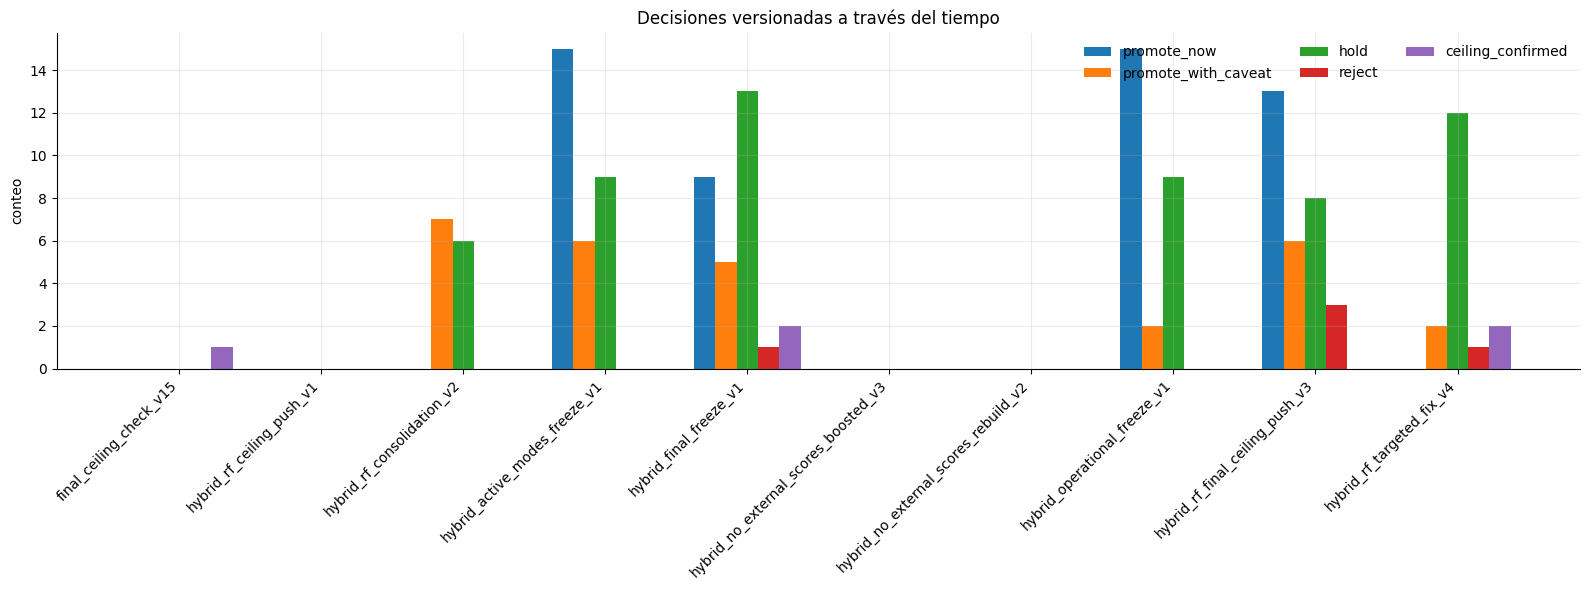

### Lectura rápida de los hitos

- 2026-04-06 | final_ceiling_check_v15 | historical_closure_check | Chequeo final de techo; el retorno esperado ya no estaba en una campaña amplia de modelado.
- 2026-04-12 | hybrid_rf_ceiling_push_v1 | full_30_pair_rf_run | Primera gran corrida híbrida RF; full modes fueron los mejores en promedio.
- 2026-04-12 | hybrid_rf_consolidation_v2 | candidate_consolidation | Consolidación quirúrgica: ningún PROMOTE_NOW; Depression quedó pendiente de corrección.
- 2026-04-13 | hybrid_active_modes_freeze_v1 | product_activation | Activación 30/30 sin vacíos: 15 high confidence, 6 moderate, 9 limited use.
- 2026-04-13 | hybrid_final_freeze_v1 | documentary_freeze | Freeze documental/operativo previo; luego fue despromovido como línea primaria por no ser la línea limpia sin scores externos.
- 2026-04-13 | hybrid_no_external_scores_boosted_v3 | targeted_boosting_on_clean_line | Mejora material en los 13/13 pares priorizados; aquí nacen los overrides de CatBoost/HGB/ExtraTrees.
- 2026-04-13 | hybri

In [18]:

timeline_sorted = timeline.sort_values(["date", "campaign"]).reset_index(drop=True)
display(timeline_sorted)

plot_df = timeline_sorted[["campaign", "promote_now", "promote_with_caveat", "hold", "reject", "ceiling_confirmed"]].fillna(0)
x = np.arange(len(plot_df))
width = 0.15

fig, ax = plt.subplots(figsize=(16, 6))
for i, col in enumerate(["promote_now", "promote_with_caveat", "hold", "reject", "ceiling_confirmed"]):
    ax.bar(x + (i - 2) * width, plot_df[col], width=width, label=col)

ax.set_xticks(x)
ax.set_xticklabels(plot_df["campaign"], rotation=45, ha="right")
ax.set_ylabel("conteo")
ax.set_title("Decisiones versionadas a través del tiempo")
ax.legend(ncol=3, frameon=False)
plt.tight_layout()
plt.show()

display(Markdown("### Lectura rápida de los hitos"))
for _, row in timeline_sorted.iterrows():
    print(f"- {row['date']} | {row['campaign']} | {row['phase']} | {row['notes']}")



## 3. Inventario maestro de los 30 modelos finales

Aquí ya no estamos mirando solo narrativa, sino el **inventario maestro activo**:

- `active_model_id`
- `config_id`
- `seed`
- `n_features`
- familia del modelo
- calibración
- política de threshold
- confidence band / confidence %
- recomendación de uso por defecto
- caveat operativo
- clase final del champion

Esta tabla es la base para auditoría fina.


In [19]:

inventory_cols = [
    "domain", "mode", "role", "active_model_id", "source_campaign", "model_family", "feature_set_id", "config_id",
    "seed", "n_features", "calibration", "threshold_policy", "threshold",
    "precision", "recall", "specificity", "balanced_accuracy", "f1", "roc_auc", "pr_auc", "brier",
    "final_class", "final_operational_class", "confidence_pct", "confidence_band",
    "recommended_for_default_use", "operational_caveat"
]
inventory = df.sort_values(["domain", "mode_order"])[inventory_cols].reset_index(drop=True)
display(inventory)

display(Markdown("### Top 10 por balanced_accuracy"))
display(inventory.sort_values("balanced_accuracy", ascending=False).head(10))

display(Markdown("### Bottom 10 por balanced_accuracy"))
display(inventory.sort_values("balanced_accuracy", ascending=True).head(10))


,domain,mode,role,active_model_id,source_campaign,model_family,feature_set_id,config_id,seed,n_features,calibration,threshold_policy,threshold,precision,recall,specificity,balanced_accuracy,f1,roc_auc,pr_auc,brier,final_class,final_operational_class,confidence_pct,confidence_band,recommended_for_default_use,operational_caveat
0,adhd,caregiver_1_3,caregiver,adhd__caregiver_1_3__rebuild_v2__rf__engineere...,rebuild_v2,rf,engineered_full,rf_regularized,20261119,58,isotonic,default_0_5,0.5000,0.6212,0.8723,0.8705,0.8714,0.7257,0.9276,0.6319,0.0868,HOLD_FOR_LIMITATION,ACTIVE_LIMITED_USE,34.3000,limited,False,limited reliability; escalate to richer mode; ...
1,adhd,caregiver_2_3,caregiver,adhd__caregiver_2_3__rebuild_v2__rf__engineere...,rebuild_v2,rf,engineered_compact,rf_regularized,20261101,43,isotonic,default_0_5,0.5000,0.7018,0.8511,0.9119,0.8815,0.7692,0.9493,0.7044,0.0726,HOLD_FOR_LIMITATION,ACTIVE_LIMITED_USE,41.8000,limited,False,limited reliability; escalate to richer mode; ...
2,adhd,caregiver_full,caregiver,adhd__caregiver_full__rebuild_v2__rf__engineer...,rebuild_v2,rf,engineered_compact,rf_balanced_subsample,20261119,53,isotonic,recall_constrained,0.4050,0.7404,0.8191,0.9301,0.8746,0.7778,0.9506,0.7119,0.0687,HOLD_FOR_LIMITATION,ACTIVE_LIMITED_USE,42.7000,limited,False,limited reliability; escalate to richer mode; ...
3,adhd,psychologist_1_3,psychologist,adhd__psychologist_1_3__rebuild_v2__rf__engine...,rebuild_v2,rf,engineered_compact,rf_balanced_subsample,20261101,30,isotonic,balanced,0.1800,0.6148,0.8830,0.8653,0.8741,0.7249,0.9259,0.6375,0.0842,HOLD_FOR_LIMITATION,ACTIVE_LIMITED_USE,34.9000,limited,False,limited reliability; escalate to richer mode; ...
4,adhd,psychologist_2_3,psychologist,adhd__psychologist_2_3__rebuild_v2__rf__engine...,rebuild_v2,rf,engineered_pruned,rf_regularized,20261101,70,isotonic,precision_min_recall,0.5050,0.7290,0.8298,0.9249,0.8773,0.7761,0.9540,0.7337,0.0680,HOLD_FOR_LIMITATION,ACTIVE_LIMITED_USE,43.8000,limited,False,limited reliability; escalate to richer mode; ...
5,adhd,psychologist_full,psychologist,adhd__psychologist_full__rebuild_v2__rf__engin...,rebuild_v2,rf,engineered_full,rf_precision_push,20261101,161,isotonic,precision_min_recall,0.5050,0.9294,0.8404,0.9845,0.9124,0.8827,0.9893,0.9271,0.0302,ROBUST_PRIMARY,ACTIVE_HIGH_CONFIDENCE,91.7000,high,True,none
6,anxiety,caregiver_1_3,caregiver,anxiety__caregiver_1_3__rebuild_v2__rf__engine...,rebuild_v2,rf,engineered_full,rf_pos_weight_mid,20261101,58,isotonic,recall_constrained,0.3200,0.8875,0.8256,0.9772,0.9014,0.8554,0.9767,0.9267,0.0368,ROBUST_PRIMARY,ACTIVE_HIGH_CONFIDENCE,88.5000,high,True,none
7,anxiety,caregiver_2_3,caregiver,anxiety__caregiver_2_3__rebuild_v2__rf__compac...,rebuild_v2,rf,compact_subset,rf_pos_weight_mid,20261119,44,isotonic,balanced,0.3350,0.8736,0.8837,0.9721,0.9279,0.8786,0.9919,0.9525,0.0307,ROBUST_PRIMARY,ACTIVE_HIGH_CONFIDENCE,89.7000,high,True,none
8,anxiety,caregiver_full,caregiver,anxiety__caregiver_full__rebuild_v2__rf__preci...,rebuild_v2,rf,precision_oriented_subset,rf_precision_push,20261101,51,isotonic,balanced,0.2950,0.9167,0.8953,0.9822,0.9388,0.9059,0.9911,0.9465,0.0274,ROBUST_PRIMARY,ACTIVE_HIGH_CONFIDENCE,95.3000,high,True,none
9,anxiety,psychologist_1_3,psychologist,anxiety__psychologist_1_3__rebuild_v2__rf__eng...,rebuild_v2,rf,engineered_full,rf_precision_push,20261119,69,isotonic,precision_min_recall,0.6100,0.9538,0.7209,0.9924,0.8567,0.8212,0.9836,0.9167,0.0356,PRIMARY_WITH_CAVEAT,ACTIVE_MODERATE_CONFIDENCE,73.4000,moderate,True,none


### Top 10 por balanced_accuracy

,domain,mode,role,active_model_id,source_campaign,model_family,feature_set_id,config_id,seed,n_features,calibration,threshold_policy,threshold,precision,recall,specificity,balanced_accuracy,f1,roc_auc,pr_auc,brier,final_class,final_operational_class,confidence_pct,confidence_band,recommended_for_default_use,operational_caveat
16,conduct,psychologist_2_3,psychologist,conduct__psychologist_2_3__rebuild_v2__rf__eng...,rebuild_v2,rf,engineered_compact,rf_balanced_subsample,20261101,45,isotonic,recall_constrained,0.5050,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0011,SUSPECT_EASY_DATASET_NEEDS_CAUTION,ACTIVE_MODERATE_CONFIDENCE,83.9000,moderate,True,possible easy-dataset inflation
13,conduct,caregiver_2_3,caregiver,conduct__caregiver_2_3__rebuild_v2__rf__engine...,rebuild_v2,rf,engineered_compact,rf_baseline,20261119,43,isotonic,recall_constrained,0.5050,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0013,SUSPECT_EASY_DATASET_NEEDS_CAUTION,ACTIVE_MODERATE_CONFIDENCE,83.9000,moderate,True,possible easy-dataset inflation
17,conduct,psychologist_full,psychologist,conduct__psychologist_full__rebuild_v2__rf__en...,rebuild_v2,rf,engineered_compact,rf_baseline,20261119,62,isotonic,recall_constrained,0.5050,1.0000,0.9938,1.0000,0.9969,0.9969,1.0000,1.0000,0.0012,SUSPECT_EASY_DATASET_NEEDS_CAUTION,ACTIVE_MODERATE_CONFIDENCE,83.9000,moderate,True,possible easy-dataset inflation
14,conduct,caregiver_full,caregiver,conduct__caregiver_full__rebuild_v2__rf__engin...,rebuild_v2,rf,engineered_compact,rf_balanced_subsample,20261101,53,isotonic,precision_min_recall,0.5050,1.0000,0.9938,1.0000,0.9969,0.9969,1.0000,1.0000,0.0013,SUSPECT_EASY_DATASET_NEEDS_CAUTION,ACTIVE_MODERATE_CONFIDENCE,83.9000,moderate,True,possible easy-dataset inflation
28,elimination,psychologist_2_3,psychologist,elimination__psychologist_2_3__rebuild_v2__rf_...,rebuild_v2,rf,engineered_pruned,rf_recall_guard,20261101,70,isotonic,precision_min_recall,0.5050,0.9615,0.9615,0.9953,0.9784,0.9615,0.9972,0.9577,0.0082,ROBUST_PRIMARY,ACTIVE_HIGH_CONFIDENCE,100.0000,high,True,none
26,elimination,caregiver_full,caregiver,elimination__caregiver_full__rebuild_v2__rf__e...,rebuild_v2,rf,engineered_compact,rf_baseline,20261101,53,isotonic,precision_min_recall,0.5050,0.9615,0.9615,0.9953,0.9784,0.9615,0.9972,0.9583,0.0081,ROBUST_PRIMARY,ACTIVE_HIGH_CONFIDENCE,100.0000,high,True,none
29,elimination,psychologist_full,psychologist,elimination__psychologist_full__rebuild_v2__rf...,rebuild_v2,rf,engineered_compact,rf_baseline,20261101,62,isotonic,precision_min_recall,0.5050,0.9434,0.9615,0.9930,0.9773,0.9524,0.9981,0.9735,0.0091,ROBUST_PRIMARY,ACTIVE_HIGH_CONFIDENCE,100.0000,high,True,none
25,elimination,caregiver_2_3,caregiver,elimination__caregiver_2_3__rebuild_v2__rf__en...,rebuild_v2,rf,engineered_compact,rf_recall_guard,20261101,43,isotonic,balanced,0.2050,0.9259,0.9615,0.9907,0.9761,0.9434,0.9971,0.9559,0.0100,ROBUST_PRIMARY,ACTIVE_HIGH_CONFIDENCE,100.0000,high,True,none
20,depression,caregiver_full,caregiver,depression__caregiver_full__boosted_v3__catboo...,boosted_v3,catboost,full_eligible,cfg_423b80f215,20270413,127,none,default_0_5,0.5000,0.8409,0.9487,0.9652,0.9569,0.8916,0.9909,0.9435,0.0294,ROBUST_PRIMARY,ACTIVE_HIGH_CONFIDENCE,91.4000,high,True,boosted override; monitor robustness
23,depression,psychologist_full,psychologist,depression__psychologist_full__boosted_v3__hgb...,boosted_v3,hgb,full_eligible,cfg_06f1522b80,20270413,152,sigmoid,balanced,0.4200,0.8690,0.9359,0.9726,0.9543,0.9012,0.9923,0.9533,0.0253,ROBUST_PRIMARY,ACTIVE_HIGH_CONFIDENCE,92.8000,high,True,boosted override; monitor robustness


### Bottom 10 por balanced_accuracy

,domain,mode,role,active_model_id,source_campaign,model_family,feature_set_id,config_id,seed,n_features,calibration,threshold_policy,threshold,precision,recall,specificity,balanced_accuracy,f1,roc_auc,pr_auc,brier,final_class,final_operational_class,confidence_pct,confidence_band,recommended_for_default_use,operational_caveat
18,depression,caregiver_1_3,caregiver,depression__caregiver_1_3__rebuild_v2__rf__pre...,rebuild_v2,rf,precision_oriented_subset,rf_baseline,20261101,20,none,recall_constrained,0.5300,0.8060,0.6585,0.9673,0.8129,0.7248,0.9583,0.7648,0.0601,HOLD_FOR_LIMITATION,ACTIVE_LIMITED_USE,18.6000,limited,False,limited reliability; escalate to richer mode; ...
9,anxiety,psychologist_1_3,psychologist,anxiety__psychologist_1_3__rebuild_v2__rf__eng...,rebuild_v2,rf,engineered_full,rf_precision_push,20261119,69,isotonic,precision_min_recall,0.6100,0.9538,0.7209,0.9924,0.8567,0.8212,0.9836,0.9167,0.0356,PRIMARY_WITH_CAVEAT,ACTIVE_MODERATE_CONFIDENCE,73.4000,moderate,True,none
21,depression,psychologist_1_3,psychologist,depression__psychologist_1_3__rebuild_v2__rf__...,rebuild_v2,rf,stability_pruned_subset,rf_baseline,20261101,30,isotonic,default_0_5,0.5000,0.7975,0.7683,0.9598,0.8640,0.7826,0.9484,0.7681,0.0565,HOLD_FOR_LIMITATION,ACTIVE_LIMITED_USE,24.5000,limited,False,limited reliability; escalate to richer mode; ...
0,adhd,caregiver_1_3,caregiver,adhd__caregiver_1_3__rebuild_v2__rf__engineere...,rebuild_v2,rf,engineered_full,rf_regularized,20261119,58,isotonic,default_0_5,0.5000,0.6212,0.8723,0.8705,0.8714,0.7257,0.9276,0.6319,0.0868,HOLD_FOR_LIMITATION,ACTIVE_LIMITED_USE,34.3000,limited,False,limited reliability; escalate to richer mode; ...
3,adhd,psychologist_1_3,psychologist,adhd__psychologist_1_3__rebuild_v2__rf__engine...,rebuild_v2,rf,engineered_compact,rf_balanced_subsample,20261101,30,isotonic,balanced,0.1800,0.6148,0.8830,0.8653,0.8741,0.7249,0.9259,0.6375,0.0842,HOLD_FOR_LIMITATION,ACTIVE_LIMITED_USE,34.9000,limited,False,limited reliability; escalate to richer mode; ...
2,adhd,caregiver_full,caregiver,adhd__caregiver_full__rebuild_v2__rf__engineer...,rebuild_v2,rf,engineered_compact,rf_balanced_subsample,20261119,53,isotonic,recall_constrained,0.4050,0.7404,0.8191,0.9301,0.8746,0.7778,0.9506,0.7119,0.0687,HOLD_FOR_LIMITATION,ACTIVE_LIMITED_USE,42.7000,limited,False,limited reliability; escalate to richer mode; ...
4,adhd,psychologist_2_3,psychologist,adhd__psychologist_2_3__rebuild_v2__rf__engine...,rebuild_v2,rf,engineered_pruned,rf_regularized,20261101,70,isotonic,precision_min_recall,0.5050,0.7290,0.8298,0.9249,0.8773,0.7761,0.9540,0.7337,0.0680,HOLD_FOR_LIMITATION,ACTIVE_LIMITED_USE,43.8000,limited,False,limited reliability; escalate to richer mode; ...
1,adhd,caregiver_2_3,caregiver,adhd__caregiver_2_3__rebuild_v2__rf__engineere...,rebuild_v2,rf,engineered_compact,rf_regularized,20261101,43,isotonic,default_0_5,0.5000,0.7018,0.8511,0.9119,0.8815,0.7692,0.9493,0.7044,0.0726,HOLD_FOR_LIMITATION,ACTIVE_LIMITED_USE,41.8000,limited,False,limited reliability; escalate to richer mode; ...
15,conduct,psychologist_1_3,psychologist,conduct__psychologist_1_3__rebuild_v2__rf__com...,rebuild_v2,rf,compact_subset,rf_recall_guard,20261101,27,sigmoid,recall_constrained,0.6450,0.9091,0.8125,0.9594,0.8859,0.8581,0.9773,0.9543,0.0585,PRIMARY_WITH_CAVEAT,ACTIVE_MODERATE_CONFIDENCE,75.7000,moderate,True,none
22,depression,psychologist_2_3,psychologist,depression__psychologist_2_3__rebuild_v2__rf__...,rebuild_v2,rf,full_eligible,rf_pos_weight_mid,20261101,102,isotonic,recall_constrained,0.5050,0.8272,0.8171,0.9648,0.8909,0.8221,0.9557,0.8330,0.0479,HOLD_FOR_LIMITATION,ACTIVE_LIMITED_USE,54.1000,limited,False,limited reliability; escalate to richer mode



## 4. Resumen portfolio-level: distribución global de métricas

Esta sección responde preguntas de portfolio:

- ¿qué tan concentradas o dispersas están las métricas?
- ¿hay colas de riesgo?
- ¿hay grupos casi perfectos que ameritan sospecha?
- ¿hay métricas muy fuertes acompañadas de baja confianza operativa?


,count,mean,std,min,25%,50%,75%,max
precision,30.0000,0.8712,0.1048,0.6148,0.8282,0.9020,0.9399,1.0000
recall,30.0000,0.8828,0.0829,0.6585,0.8324,0.8837,0.9583,1.0000
specificity,30.0000,0.9675,0.0351,0.8653,0.9611,0.9784,0.9920,1.0000
balanced_accuracy,30.0000,0.9252,0.0502,0.8129,0.8826,0.9304,0.9713,1.0000
f1,30.0000,0.8738,0.0840,0.7248,0.8214,0.8836,0.9340,1.0000
roc_auc,30.0000,0.9788,0.0227,0.9259,0.9576,0.9904,0.9970,1.0000
pr_auc,30.0000,0.8921,0.1127,0.6319,0.8356,0.9454,0.9581,1.0000
brier,30.0000,0.0353,0.0257,0.0011,0.0126,0.0302,0.0565,0.0868


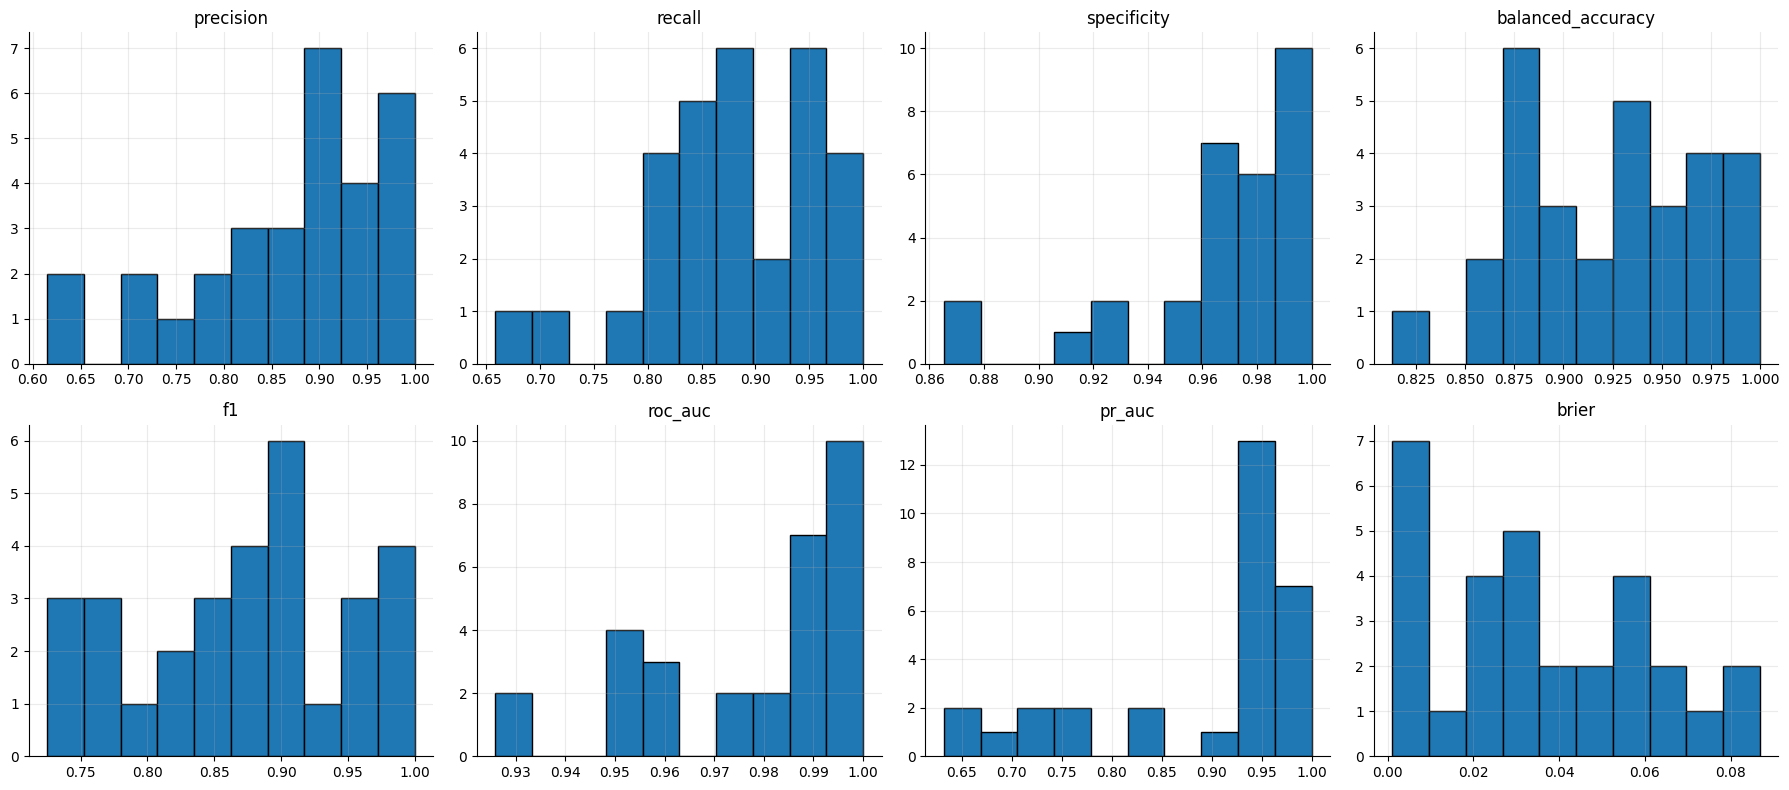

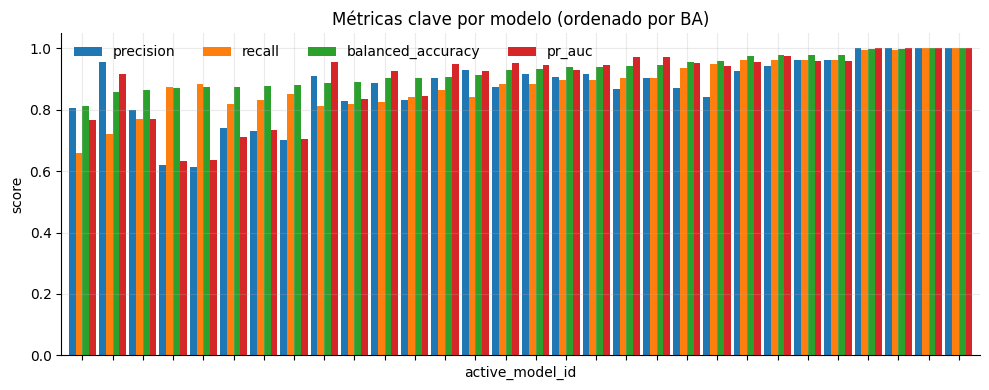

In [20]:

metric_view = df[["precision", "recall", "specificity", "balanced_accuracy", "f1", "roc_auc", "pr_auc", "brier"]]
display(metric_view.describe().T)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()
for ax, col in zip(axes, metric_view.columns):
    ax.hist(metric_view[col], bins=10, edgecolor="black")
    ax.set_title(col)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
df.sort_values("balanced_accuracy").plot(
    x="active_model_id",
    y=["precision", "recall", "balanced_accuracy", "pr_auc"],
    kind="bar",
    ax=ax,
    width=0.9
)
ax.set_title("Métricas clave por modelo (ordenado por BA)")
ax.set_xlabel("active_model_id")
ax.set_ylabel("score")
ax.legend(frameon=False, ncol=4)
ax.tick_params(axis="x", labelbottom=False)
plt.tight_layout()
plt.show()



## 5. Heatmaps: lectura por dominio × modo

Los heatmaps son de los gráficos más importantes de este notebook porque permiten ver inmediatamente:

- qué dominios tienen consistencia transversal,
- qué modos cortos se quedan atrás,
- dónde el thresholding favoreció recall vs precision,
- y dónde la línea boosted cambió de verdad el panorama.


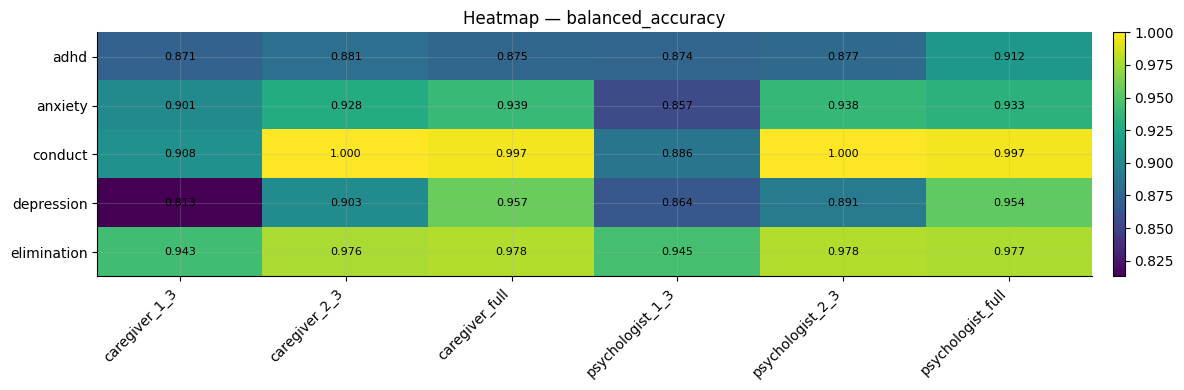

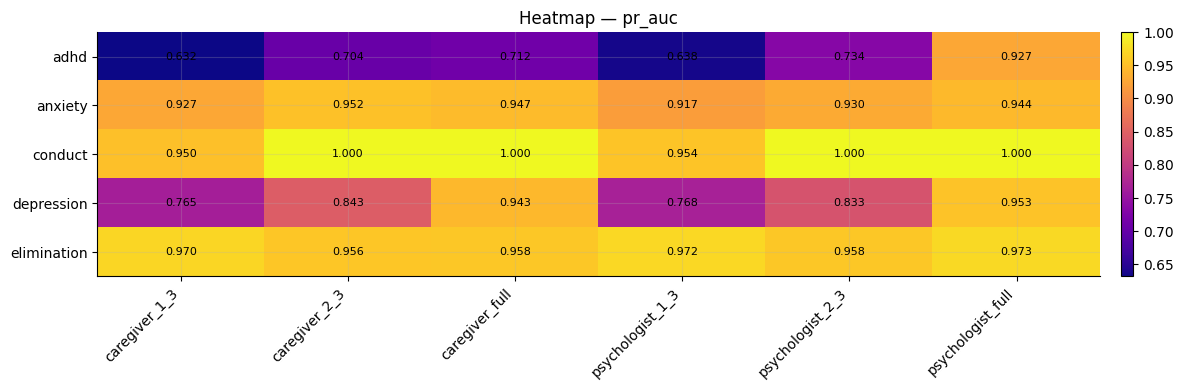

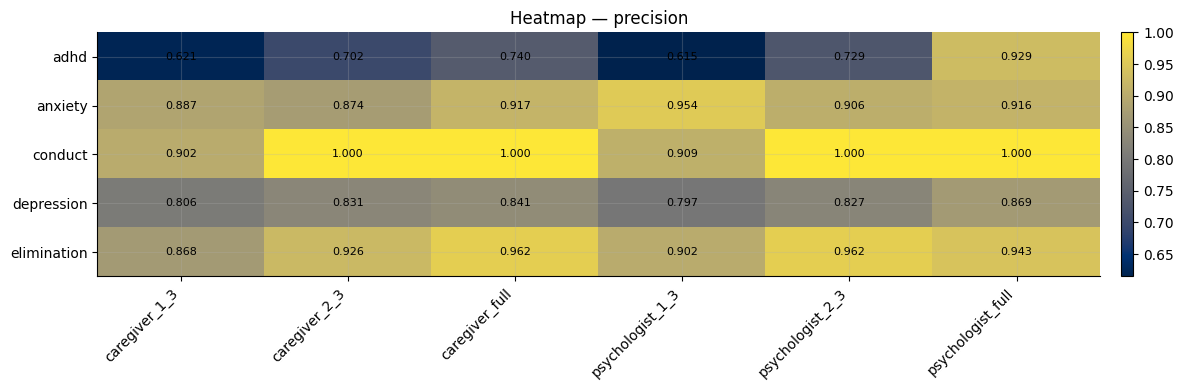

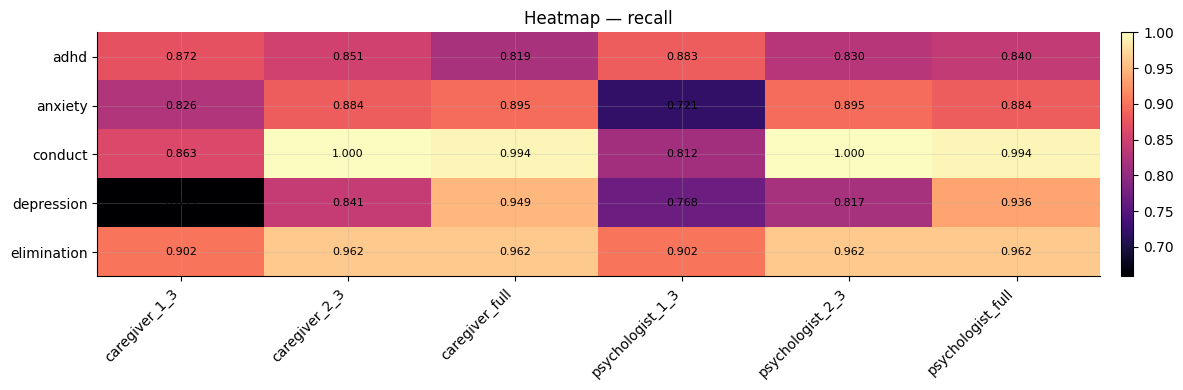

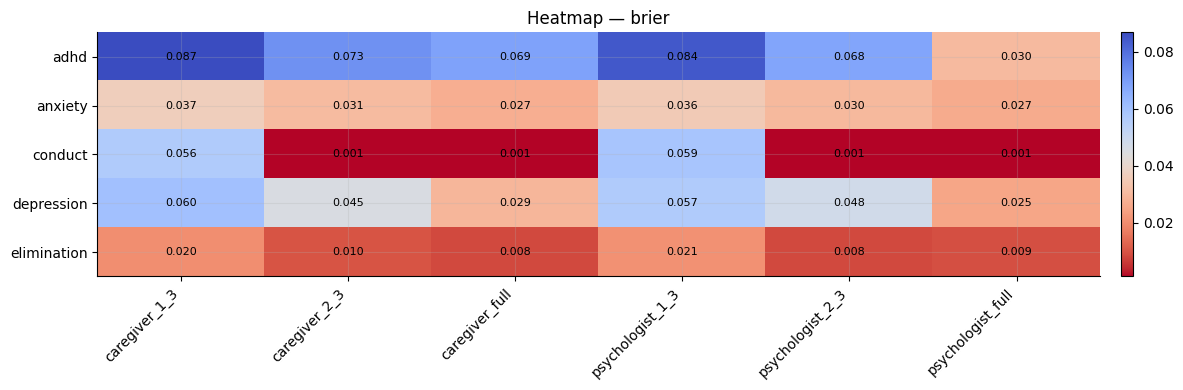

In [21]:

mode_order = ["caregiver_1_3", "caregiver_2_3", "caregiver_full", "psychologist_1_3", "psychologist_2_3", "psychologist_full"]

def simple_heatmap(metric, cmap="viridis"):
    piv = df.pivot(index="domain", columns="mode", values=metric).reindex(columns=mode_order)
    fig, ax = plt.subplots(figsize=(12, 4))
    im = ax.imshow(piv.values, aspect="auto", cmap=cmap)
    ax.set_xticks(range(len(piv.columns)))
    ax.set_xticklabels(piv.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(piv.index)))
    ax.set_yticklabels(piv.index)
    ax.set_title(f"Heatmap — {metric}")
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            ax.text(j, i, f"{piv.iloc[i, j]:.3f}", ha="center", va="center", fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
    plt.tight_layout()
    plt.show()

for metric, cmap in [
    ("balanced_accuracy", "viridis"),
    ("pr_auc", "plasma"),
    ("precision", "cividis"),
    ("recall", "magma"),
    ("brier", "coolwarm_r"),
]:
    simple_heatmap(metric, cmap=cmap)



## 6. Gráficos de frontera: trade-offs reales del portfolio

Aquí buscamos patrones que normalmente quedan ocultos en tablas:

- **precision vs recall**
- **balanced_accuracy vs PR-AUC**
- **ROC-AUC vs Brier**
- **threshold vs recall / threshold vs precision**
- **n_features vs balanced_accuracy**

Esto ayuda a detectar:
- modelos muy “agresivos” en recall,
- modelos muy selectivos,
- configuraciones que mejoran discriminación pero no necesariamente calibración,
- y señales de saturación o sobredimensión de features.


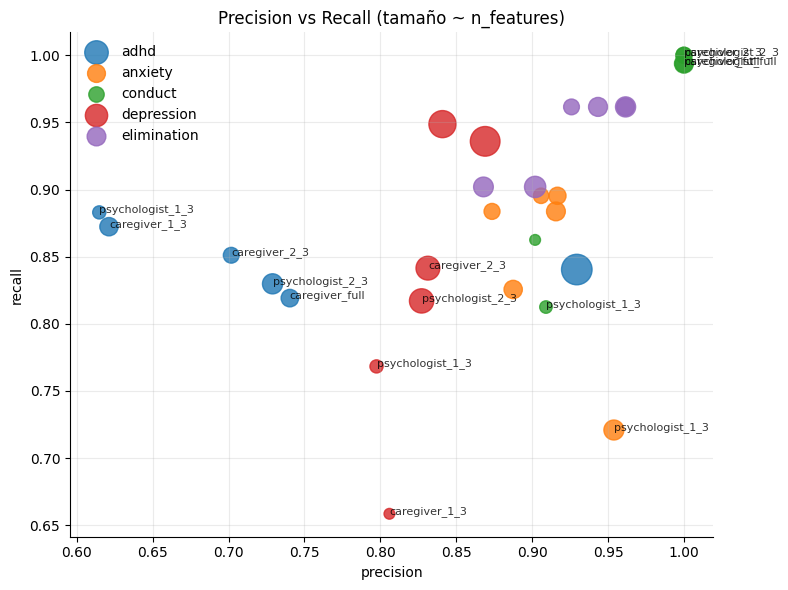

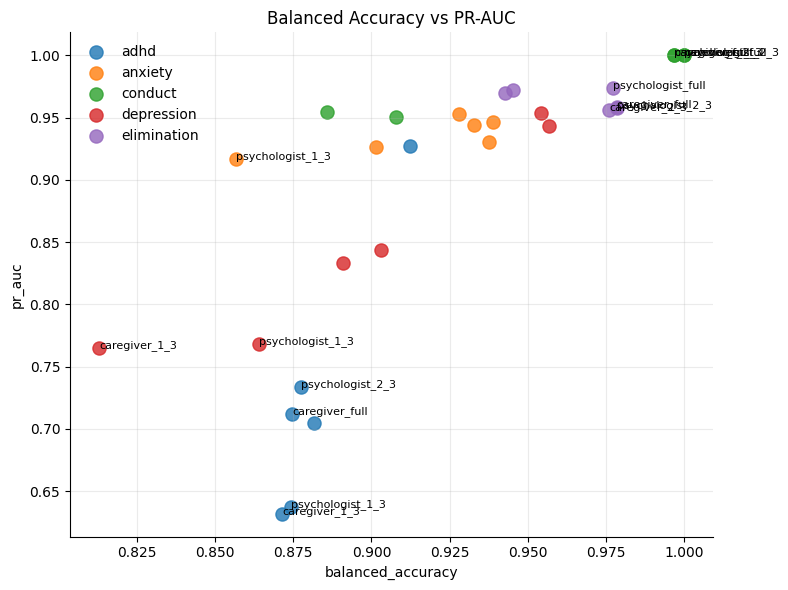

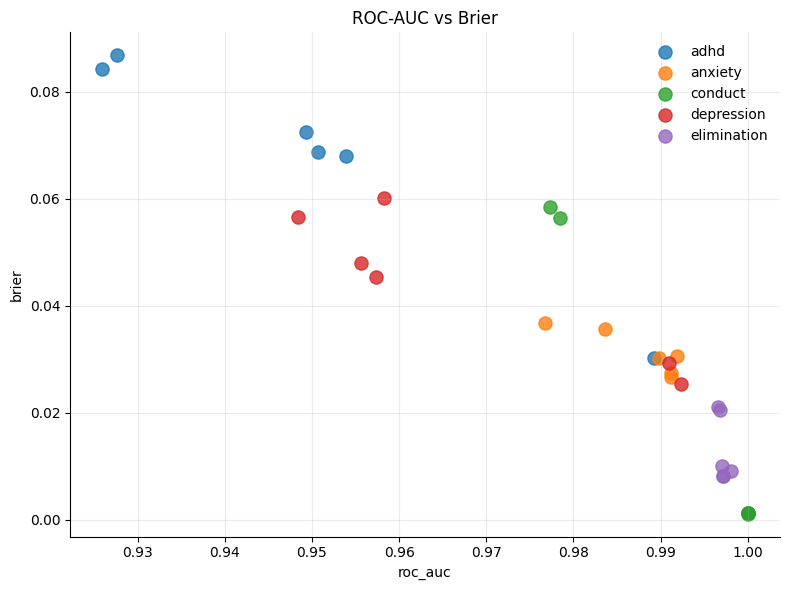

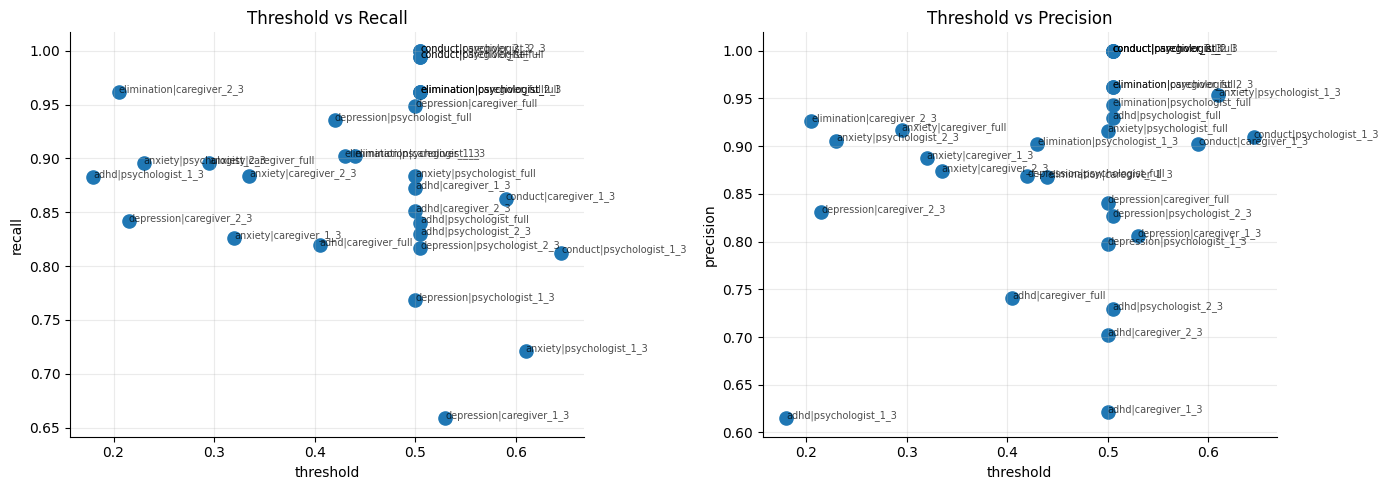

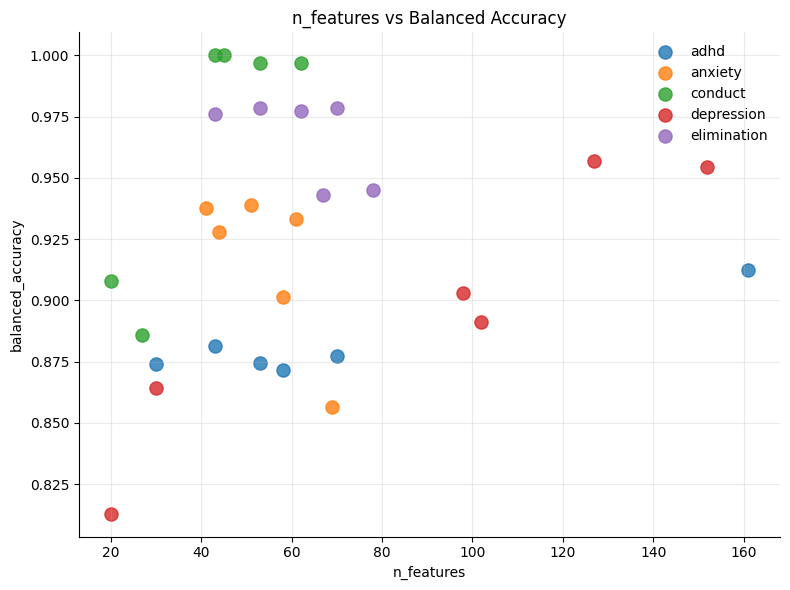

In [22]:

domain_colors = {d: c for d, c in zip(sorted(df["domain"].unique()), ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"])}

fig, ax = plt.subplots(figsize=(8, 6))
for domain, g in df.groupby("domain"):
    ax.scatter(g["precision"], g["recall"], s=g["n_features"]*3, label=domain, alpha=0.8)
for _, r in df.iterrows():
    if r["final_class"] != "ROBUST_PRIMARY" or r["confidence_band"] in ["low", "limited"]:
        ax.annotate(r["mode"], (r["precision"], r["recall"]), fontsize=8, alpha=0.8)
ax.set_xlabel("precision")
ax.set_ylabel("recall")
ax.set_title("Precision vs Recall (tamaño ~ n_features)")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
for domain, g in df.groupby("domain"):
    ax.scatter(g["balanced_accuracy"], g["pr_auc"], s=90, label=domain, alpha=0.8)
for _, r in df.iterrows():
    if r["balanced_accuracy"] > 0.97 or r["balanced_accuracy"] < 0.88:
        ax.annotate(r["mode"], (r["balanced_accuracy"], r["pr_auc"]), fontsize=8)
ax.set_xlabel("balanced_accuracy")
ax.set_ylabel("pr_auc")
ax.set_title("Balanced Accuracy vs PR-AUC")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
for domain, g in df.groupby("domain"):
    ax.scatter(g["roc_auc"], g["brier"], s=90, label=domain, alpha=0.8)
ax.set_xlabel("roc_auc")
ax.set_ylabel("brier")
ax.set_title("ROC-AUC vs Brier")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(df["threshold"], df["recall"], s=90)
for _, r in df.iterrows():
    axes[0].annotate(f"{r['domain']}|{r['mode']}", (r["threshold"], r["recall"]), fontsize=7, alpha=0.7)
axes[0].set_title("Threshold vs Recall")
axes[0].set_xlabel("threshold")
axes[0].set_ylabel("recall")

axes[1].scatter(df["threshold"], df["precision"], s=90)
for _, r in df.iterrows():
    axes[1].annotate(f"{r['domain']}|{r['mode']}", (r["threshold"], r["precision"]), fontsize=7, alpha=0.7)
axes[1].set_title("Threshold vs Precision")
axes[1].set_xlabel("threshold")
axes[1].set_ylabel("precision")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
for domain, g in df.groupby("domain"):
    ax.scatter(g["n_features"], g["balanced_accuracy"], s=90, label=domain, alpha=0.8)
ax.set_xlabel("n_features")
ax.set_ylabel("balanced_accuracy")
ax.set_title("n_features vs Balanced Accuracy")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()



## 7. Segmentación por dominio, rol, profundidad y familia

Ahora resumimos el portfolio con varias lentes:

- **por dominio**
- **por rol (caregiver vs psychologist)**
- **por profundidad (1/3, 2/3, full)**
- **por familia de modelo**
- **por calibración**
- **por clase final**

Esto permite responder preguntas como:
- ¿el cuestionario full realmente empuja el desempeño?
- ¿los modos psychologist son mejores siempre?
- ¿los overrides boosted cambian de forma material el ranking?


### Resumen por dominio

,precision,recall,specificity,balanced_accuracy,pr_auc,brier
domain,,,,,,
elimination,0.9270,0.9417,0.9911,0.9664,0.9646,0.0128
conduct,0.9685,0.9437,0.9854,0.9646,0.9841,0.0200
anxiety,0.9089,0.8508,0.9810,0.9159,0.9362,0.0313
depression,0.8286,0.8283,0.9658,0.8970,0.8510,0.0441
adhd,0.7228,0.8493,0.9145,0.8819,0.7244,0.0684


### Resumen por rol

,precision,recall,specificity,balanced_accuracy,pr_auc,brier
role,,,,,,
psychologist,0.8839,0.8804,0.9708,0.9256,0.9001,0.0336
caregiver,0.8584,0.8851,0.9643,0.9247,0.8840,0.0370


### Resumen por profundidad

,precision,recall,specificity,balanced_accuracy,pr_auc,brier
mode_depth,,,,,,
1/3,0.8262,0.8208,0.9517,0.8862,0.8493,0.0516
2/3,0.8756,0.9042,0.9704,0.9373,0.8911,0.0315
full,0.9117,0.9234,0.9805,0.9519,0.9358,0.0228


### Resumen por familia

,precision,recall,specificity,balanced_accuracy,pr_auc,brier
model_family,,,,,,
catboost,0.8409,0.9487,0.9652,0.9569,0.9435,0.0294
hgb,0.8690,0.9359,0.9726,0.9543,0.9533,0.0253
extra_trees,0.8849,0.9020,0.9860,0.9440,0.9712,0.0207
rf,0.8713,0.8767,0.9660,0.9214,0.8816,0.0371


### Resumen por clase final

,precision,recall,specificity,balanced_accuracy,pr_auc,brier
final_class,,,,,,
SUSPECT_EASY_DATASET_NEEDS_CAUTION,1.0000,0.9969,1.0000,0.9984,1.0000,0.0012
ROBUST_PRIMARY,0.9069,0.9081,0.9810,0.9445,0.9508,0.0247
HOLD_FOR_LIMITATION,0.7410,0.8156,0.9288,0.8722,0.7365,0.0656
PRIMARY_WITH_CAVEAT,0.9315,0.7667,0.9759,0.8713,0.9355,0.0471


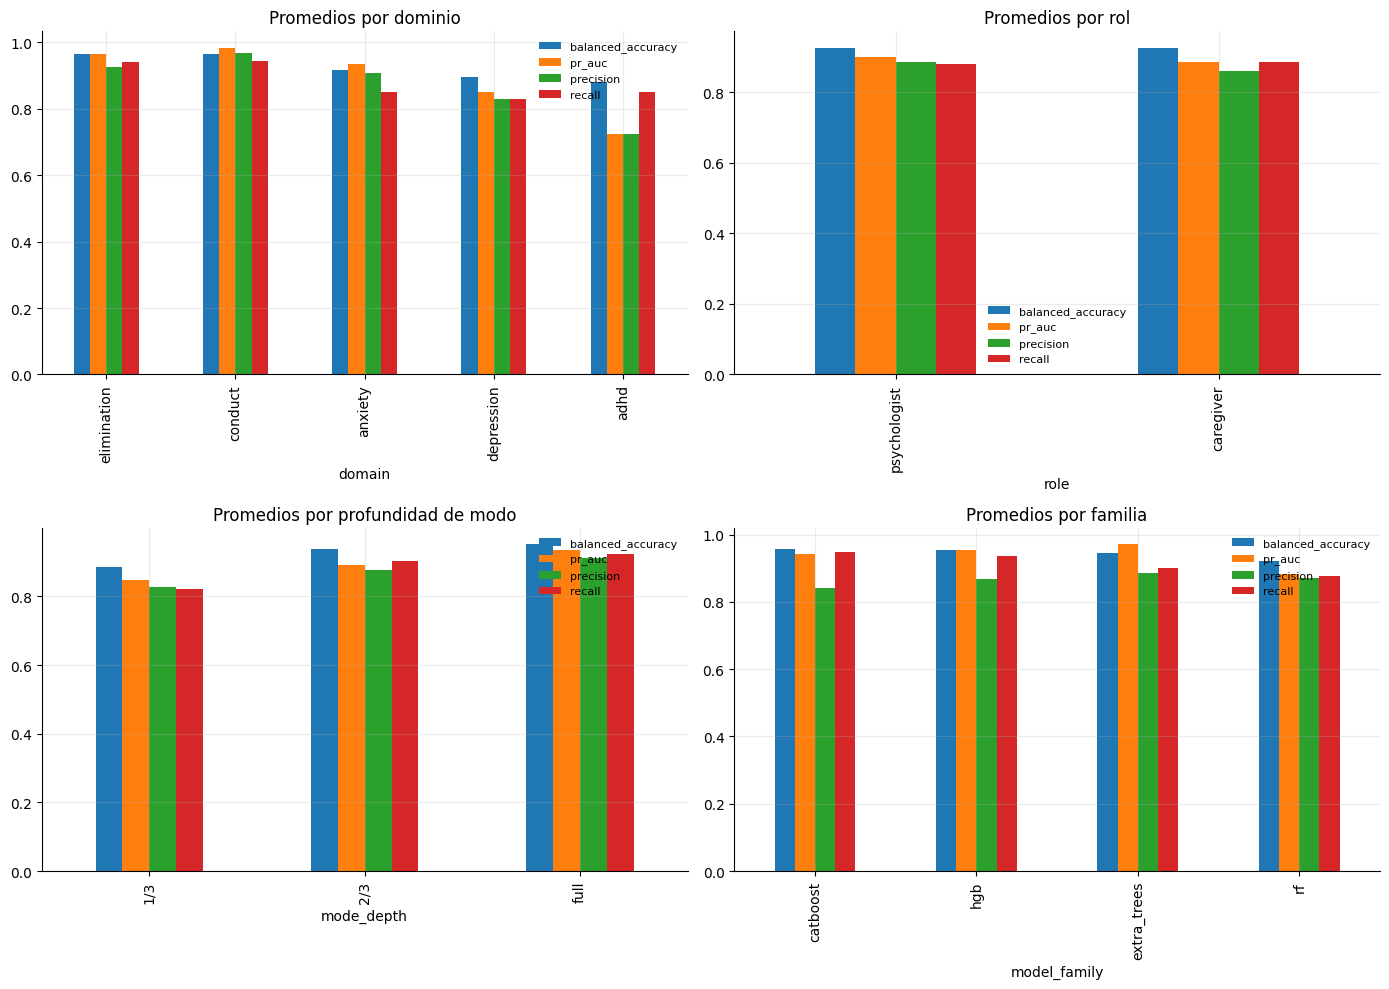

In [23]:

domain_summary = df.groupby("domain")[["precision", "recall", "specificity", "balanced_accuracy", "pr_auc", "brier"]].mean().sort_values("balanced_accuracy", ascending=False)
role_summary = df.groupby("role")[["precision", "recall", "specificity", "balanced_accuracy", "pr_auc", "brier"]].mean().sort_values("balanced_accuracy", ascending=False)
depth_summary = df.groupby("mode_depth")[["precision", "recall", "specificity", "balanced_accuracy", "pr_auc", "brier"]].mean().reindex(["1/3", "2/3", "full"])
family_summary = df.groupby("model_family")[["precision", "recall", "specificity", "balanced_accuracy", "pr_auc", "brier"]].mean().sort_values("balanced_accuracy", ascending=False)
class_summary = df.groupby("final_class")[["precision", "recall", "specificity", "balanced_accuracy", "pr_auc", "brier"]].mean().sort_values("balanced_accuracy", ascending=False)

display(Markdown("### Resumen por dominio"))
display(domain_summary)
display(Markdown("### Resumen por rol"))
display(role_summary)
display(Markdown("### Resumen por profundidad"))
display(depth_summary)
display(Markdown("### Resumen por familia"))
display(family_summary)
display(Markdown("### Resumen por clase final"))
display(class_summary)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
domain_summary[["balanced_accuracy", "pr_auc", "precision", "recall"]].plot(kind="bar", ax=axes[0,0], title="Promedios por dominio")
role_summary[["balanced_accuracy", "pr_auc", "precision", "recall"]].plot(kind="bar", ax=axes[0,1], title="Promedios por rol")
depth_summary[["balanced_accuracy", "pr_auc", "precision", "recall"]].plot(kind="bar", ax=axes[1,0], title="Promedios por profundidad de modo")
family_summary[["balanced_accuracy", "pr_auc", "precision", "recall"]].plot(kind="bar", ax=axes[1,1], title="Promedios por familia")
for ax in axes.ravel():
    ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()



## 8. Riesgos, fragilidad y caveats

No basta con ver métricas altas. En CognIA hay varios tipos de alertas que deben interpretarse de manera distinta:

- `HOLD_FOR_LIMITATION`
- `PRIMARY_WITH_CAVEAT`
- `SUSPECT_EASY_DATASET_NEEDS_CAUTION`
- `ACTIVE_LIMITED_USE`
- `confidence_band` limitada/baja
- `overfit_flag = yes`
- `dataset_ease_flag = yes`

Esta sección hace visible ese mapa de riesgos.


,domain,mode,model_family,feature_set_id,n_features,balanced_accuracy,pr_auc,brier,final_class,final_operational_class,confidence_pct,confidence_band,overfit_flag,dataset_ease_flag,operational_caveat
0,adhd,caregiver_1_3,rf,engineered_full,58,0.8714,0.6319,0.0868,HOLD_FOR_LIMITATION,ACTIVE_LIMITED_USE,34.3000,limited,False,False,limited reliability; escalate to richer mode; ...
1,adhd,caregiver_2_3,rf,engineered_compact,43,0.8815,0.7044,0.0726,HOLD_FOR_LIMITATION,ACTIVE_LIMITED_USE,41.8000,limited,False,False,limited reliability; escalate to richer mode; ...
2,adhd,caregiver_full,rf,engineered_compact,53,0.8746,0.7119,0.0687,HOLD_FOR_LIMITATION,ACTIVE_LIMITED_USE,42.7000,limited,False,False,limited reliability; escalate to richer mode; ...
3,adhd,psychologist_1_3,rf,engineered_compact,30,0.8741,0.6375,0.0842,HOLD_FOR_LIMITATION,ACTIVE_LIMITED_USE,34.9000,limited,False,False,limited reliability; escalate to richer mode; ...
4,adhd,psychologist_2_3,rf,engineered_pruned,70,0.8773,0.7337,0.0680,HOLD_FOR_LIMITATION,ACTIVE_LIMITED_USE,43.8000,limited,False,False,limited reliability; escalate to richer mode; ...
18,depression,caregiver_1_3,rf,precision_oriented_subset,20,0.8129,0.7648,0.0601,HOLD_FOR_LIMITATION,ACTIVE_LIMITED_USE,18.6000,limited,True,False,limited reliability; escalate to richer mode; ...
19,depression,caregiver_2_3,rf,full_eligible,98,0.9031,0.8434,0.0455,HOLD_FOR_LIMITATION,ACTIVE_LIMITED_USE,56.3000,low,False,False,limited reliability; escalate to richer mode
21,depression,psychologist_1_3,rf,stability_pruned_subset,30,0.8640,0.7681,0.0565,HOLD_FOR_LIMITATION,ACTIVE_LIMITED_USE,24.5000,limited,True,False,limited reliability; escalate to richer mode; ...
22,depression,psychologist_2_3,rf,full_eligible,102,0.8909,0.8330,0.0479,HOLD_FOR_LIMITATION,ACTIVE_LIMITED_USE,54.1000,limited,False,False,limited reliability; escalate to richer mode
9,anxiety,psychologist_1_3,rf,engineered_full,69,0.8567,0.9167,0.0356,PRIMARY_WITH_CAVEAT,ACTIVE_MODERATE_CONFIDENCE,73.4000,moderate,False,False,none


### Conteos de riesgo

,risk,count
0,hold_for_limitation,9
1,primary_with_caveat,2
2,suspect_easy_dataset,4
3,overfit_flag_yes,2
4,dataset_ease_flag_yes,4
5,confidence_limited_or_low,9


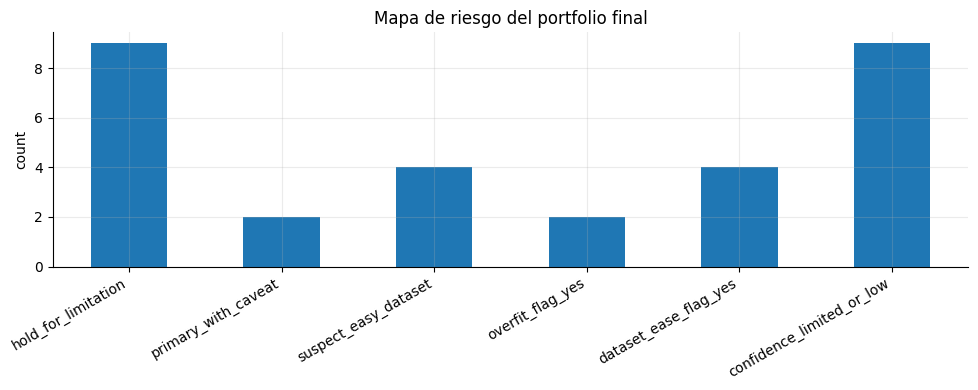

### Pares que combinan métricas fuertes con caveat relevante

,domain,mode,balanced_accuracy,pr_auc,final_class,confidence_band,operational_caveat
19,depression,caregiver_2_3,0.9031,0.8434,HOLD_FOR_LIMITATION,low,limited reliability; escalate to richer mode
22,depression,psychologist_2_3,0.8909,0.8330,HOLD_FOR_LIMITATION,limited,limited reliability; escalate to richer mode
1,adhd,caregiver_2_3,0.8815,0.7044,HOLD_FOR_LIMITATION,limited,limited reliability; escalate to richer mode; ...
4,adhd,psychologist_2_3,0.8773,0.7337,HOLD_FOR_LIMITATION,limited,limited reliability; escalate to richer mode; ...
2,adhd,caregiver_full,0.8746,0.7119,HOLD_FOR_LIMITATION,limited,limited reliability; escalate to richer mode; ...
3,adhd,psychologist_1_3,0.8741,0.6375,HOLD_FOR_LIMITATION,limited,limited reliability; escalate to richer mode; ...
0,adhd,caregiver_1_3,0.8714,0.6319,HOLD_FOR_LIMITATION,limited,limited reliability; escalate to richer mode; ...
21,depression,psychologist_1_3,0.8640,0.7681,HOLD_FOR_LIMITATION,limited,limited reliability; escalate to richer mode; ...
13,conduct,caregiver_2_3,1.0000,1.0000,SUSPECT_EASY_DATASET_NEEDS_CAUTION,moderate,possible easy-dataset inflation
16,conduct,psychologist_2_3,1.0000,1.0000,SUSPECT_EASY_DATASET_NEEDS_CAUTION,moderate,possible easy-dataset inflation


In [24]:

risk_table = df.sort_values(["final_class", "domain", "mode_order"])[[
    "domain", "mode", "model_family", "feature_set_id", "n_features",
    "balanced_accuracy", "pr_auc", "brier",
    "final_class", "final_operational_class", "confidence_pct", "confidence_band",
    "overfit_flag", "dataset_ease_flag", "operational_caveat"
]]
display(risk_table)

display(Markdown("### Conteos de riesgo"))
risk_counts = pd.Series({
    "hold_for_limitation": int(df["final_class"].eq("HOLD_FOR_LIMITATION").sum()),
    "primary_with_caveat": int(df["final_class"].eq("PRIMARY_WITH_CAVEAT").sum()),
    "suspect_easy_dataset": int(df["final_class"].eq("SUSPECT_EASY_DATASET_NEEDS_CAUTION").sum()),
    "overfit_flag_yes": int(df["overfit_flag"].fillna(False).sum()),
    "dataset_ease_flag_yes": int(df["dataset_ease_flag"].fillna(False).sum()),
    "confidence_limited_or_low": int(df["confidence_band"].isin(["limited", "low"]).sum()),
}).rename_axis("risk").reset_index(name="count")
display(risk_counts)

fig, ax = plt.subplots(figsize=(10, 4))
risk_counts.plot(x="risk", y="count", kind="bar", ax=ax, legend=False)
ax.set_title("Mapa de riesgo del portfolio final")
ax.set_xlabel("")
ax.set_ylabel("count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

display(Markdown("### Pares que combinan métricas fuertes con caveat relevante"))
flagged = df[
    (
        (df["balanced_accuracy"] >= 0.90) &
        (df["final_class"].isin(["PRIMARY_WITH_CAVEAT", "SUSPECT_EASY_DATASET_NEEDS_CAUTION"]))
    ) |
    (
        (df["balanced_accuracy"] >= 0.85) &
        (df["confidence_band"].isin(["limited", "low"]))
    )
][[
    "domain", "mode", "balanced_accuracy", "pr_auc", "final_class", "confidence_band", "operational_caveat"
]].sort_values(["final_class", "balanced_accuracy"], ascending=[True, False])
display(flagged)



## 9. Overrides boosted: dónde realmente se movió la frontera

Una parte central de la historia metodológica es que la línea final **no** es simplemente RF en todos lados. Hay 4 overrides operativos desde `boosted_v3`:

- `depression caregiver_full` → **CatBoost**
- `depression psychologist_full` → **HGB**
- `elimination caregiver_1_3` → **ExtraTrees**
- `elimination psychologist_1_3` → **ExtraTrees**

Esto solo se aceptó donde la mejora fue suficiente y trazable.


### Overrides boosted

,domain,mode,model_family,feature_set_id,n_features,precision,recall,balanced_accuracy,pr_auc,brier,confidence_pct,final_class,operational_caveat
20,depression,caregiver_full,catboost,full_eligible,127,0.8409,0.9487,0.9569,0.9435,0.0294,91.4000,ROBUST_PRIMARY,boosted override; monitor robustness
23,depression,psychologist_full,hgb,full_eligible,152,0.8690,0.9359,0.9543,0.9533,0.0253,92.8000,ROBUST_PRIMARY,boosted override; monitor robustness
24,elimination,caregiver_1_3,extra_trees,boosted_eng_full,67,0.8679,0.9020,0.9428,0.9700,0.0204,92.4000,ROBUST_PRIMARY,boosted override; monitor robustness
27,elimination,psychologist_1_3,extra_trees,boosted_eng_full,78,0.9020,0.9020,0.9452,0.9724,0.0210,96.9000,ROBUST_PRIMARY,boosted override; monitor robustness


,boosted_override_mean,non_boosted_mean,delta_boosted_minus_non_boosted
precision,0.8700,0.8713,-0.0014
recall,0.9221,0.8767,0.0454
balanced_accuracy,0.9498,0.9214,0.0284
pr_auc,0.9598,0.8816,0.0782
brier,0.0240,0.0371,-0.0130


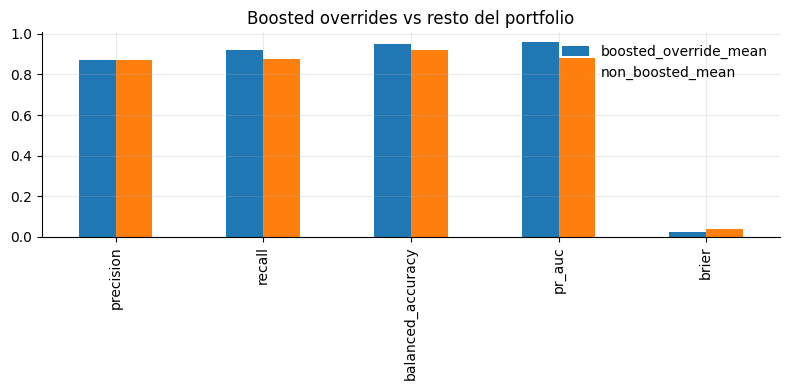

In [25]:

boosted = df[df["is_boosted_override"]].copy()
non_boosted = df[~df["is_boosted_override"]].copy()

display(Markdown("### Overrides boosted"))
display(boosted[[
    "domain", "mode", "model_family", "feature_set_id", "n_features",
    "precision", "recall", "balanced_accuracy", "pr_auc", "brier",
    "confidence_pct", "final_class", "operational_caveat"
]])

comparison = pd.DataFrame({
    "boosted_override_mean": boosted[["precision", "recall", "balanced_accuracy", "pr_auc", "brier"]].mean(),
    "non_boosted_mean": non_boosted[["precision", "recall", "balanced_accuracy", "pr_auc", "brier"]].mean(),
})
comparison["delta_boosted_minus_non_boosted"] = comparison["boosted_override_mean"] - comparison["non_boosted_mean"]
display(comparison)

fig, ax = plt.subplots(figsize=(8, 4))
comparison[["boosted_override_mean", "non_boosted_mean"]].plot(kind="bar", ax=ax)
ax.set_title("Boosted overrides vs resto del portfolio")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()



## 10. Análisis detallado por dominio

En esta parte se descompone cada dominio en sus 6 modos.  
Para cada dominio generamos:

- tabla de inventario detallado,
- gráfica de métricas clave por modo,
- gráfica de threshold / `n_features` / confianza,
- lectura experta de los patrones más visibles.


### Dominio: ADHD

,mode,model_family,feature_set_id,config_id,seed,n_features,calibration,threshold_policy,threshold,precision,recall,specificity,balanced_accuracy,f1,roc_auc,pr_auc,brier,final_class,final_operational_class,confidence_pct,confidence_band,operational_caveat
0,caregiver_1_3,rf,engineered_full,rf_regularized,20261119,58,isotonic,default_0_5,0.5000,0.6212,0.8723,0.8705,0.8714,0.7257,0.9276,0.6319,0.0868,HOLD_FOR_LIMITATION,ACTIVE_LIMITED_USE,34.3000,limited,limited reliability; escalate to richer mode; ...
1,caregiver_2_3,rf,engineered_compact,rf_regularized,20261101,43,isotonic,default_0_5,0.5000,0.7018,0.8511,0.9119,0.8815,0.7692,0.9493,0.7044,0.0726,HOLD_FOR_LIMITATION,ACTIVE_LIMITED_USE,41.8000,limited,limited reliability; escalate to richer mode; ...
2,caregiver_full,rf,engineered_compact,rf_balanced_subsample,20261119,53,isotonic,recall_constrained,0.4050,0.7404,0.8191,0.9301,0.8746,0.7778,0.9506,0.7119,0.0687,HOLD_FOR_LIMITATION,ACTIVE_LIMITED_USE,42.7000,limited,limited reliability; escalate to richer mode; ...
3,psychologist_1_3,rf,engineered_compact,rf_balanced_subsample,20261101,30,isotonic,balanced,0.1800,0.6148,0.8830,0.8653,0.8741,0.7249,0.9259,0.6375,0.0842,HOLD_FOR_LIMITATION,ACTIVE_LIMITED_USE,34.9000,limited,limited reliability; escalate to richer mode; ...
4,psychologist_2_3,rf,engineered_pruned,rf_regularized,20261101,70,isotonic,precision_min_recall,0.5050,0.7290,0.8298,0.9249,0.8773,0.7761,0.9540,0.7337,0.0680,HOLD_FOR_LIMITATION,ACTIVE_LIMITED_USE,43.8000,limited,limited reliability; escalate to richer mode; ...
5,psychologist_full,rf,engineered_full,rf_precision_push,20261101,161,isotonic,precision_min_recall,0.5050,0.9294,0.8404,0.9845,0.9124,0.8827,0.9893,0.9271,0.0302,ROBUST_PRIMARY,ACTIVE_HIGH_CONFIDENCE,91.7000,high,none


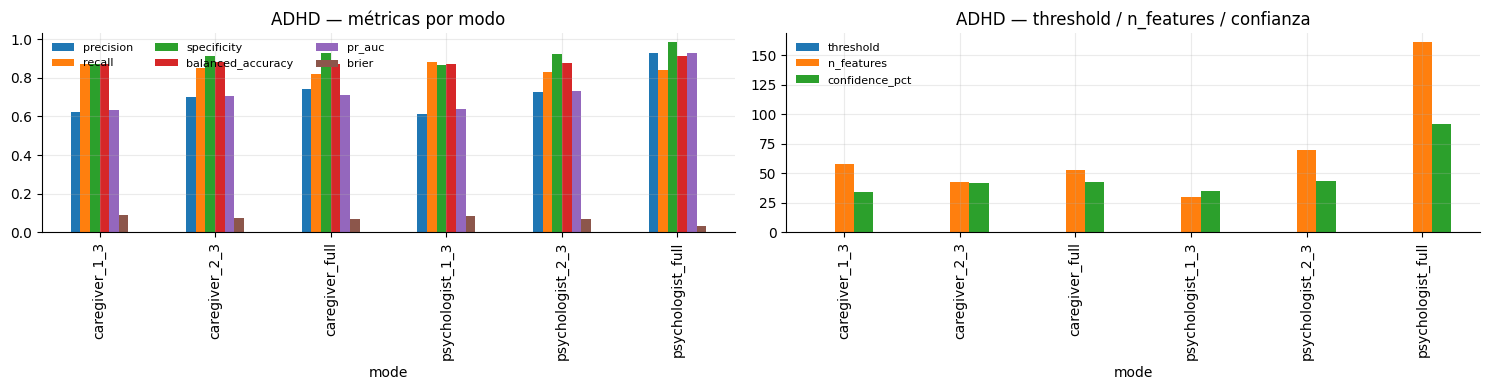

- Mejor BA: **psychologist_full** (0.9124)
- Peor BA: **caregiver_1_3** (0.8714)
- Mejor PR-AUC: **psychologist_full** (0.9271)
- Modos con confianza limitada/baja: caregiver_1_3, caregiver_2_3, caregiver_full, psychologist_1_3, psychologist_2_3



### Dominio: ANXIETY

,mode,model_family,feature_set_id,config_id,seed,n_features,calibration,threshold_policy,threshold,precision,recall,specificity,balanced_accuracy,f1,roc_auc,pr_auc,brier,final_class,final_operational_class,confidence_pct,confidence_band,operational_caveat
6,caregiver_1_3,rf,engineered_full,rf_pos_weight_mid,20261101,58,isotonic,recall_constrained,0.3200,0.8875,0.8256,0.9772,0.9014,0.8554,0.9767,0.9267,0.0368,ROBUST_PRIMARY,ACTIVE_HIGH_CONFIDENCE,88.5000,high,none
7,caregiver_2_3,rf,compact_subset,rf_pos_weight_mid,20261119,44,isotonic,balanced,0.3350,0.8736,0.8837,0.9721,0.9279,0.8786,0.9919,0.9525,0.0307,ROBUST_PRIMARY,ACTIVE_HIGH_CONFIDENCE,89.7000,high,none
8,caregiver_full,rf,precision_oriented_subset,rf_precision_push,20261101,51,isotonic,balanced,0.2950,0.9167,0.8953,0.9822,0.9388,0.9059,0.9911,0.9465,0.0274,ROBUST_PRIMARY,ACTIVE_HIGH_CONFIDENCE,95.3000,high,none
9,psychologist_1_3,rf,engineered_full,rf_precision_push,20261119,69,isotonic,precision_min_recall,0.6100,0.9538,0.7209,0.9924,0.8567,0.8212,0.9836,0.9167,0.0356,PRIMARY_WITH_CAVEAT,ACTIVE_MODERATE_CONFIDENCE,73.4000,moderate,none
10,psychologist_2_3,rf,precision_oriented_subset,rf_precision_push,20261101,41,isotonic,balanced,0.2300,0.9059,0.8953,0.9797,0.9375,0.9006,0.9898,0.9303,0.0302,ROBUST_PRIMARY,ACTIVE_HIGH_CONFIDENCE,93.8000,high,none
11,psychologist_full,rf,precision_oriented_subset,rf_precision_push,20261101,61,isotonic,default_0_5,0.5000,0.9157,0.8837,0.9822,0.9330,0.8994,0.9912,0.9442,0.0268,ROBUST_PRIMARY,ACTIVE_HIGH_CONFIDENCE,94.5000,high,none


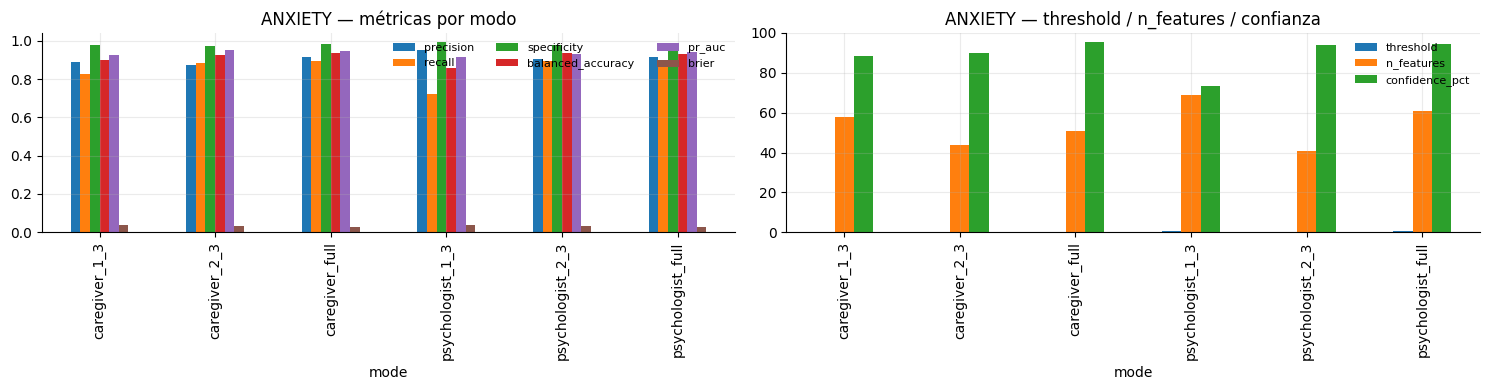

- Mejor BA: **caregiver_full** (0.9388)
- Peor BA: **psychologist_1_3** (0.8567)
- Mejor PR-AUC: **caregiver_2_3** (0.9525)



### Dominio: CONDUCT

,mode,model_family,feature_set_id,config_id,seed,n_features,calibration,threshold_policy,threshold,precision,recall,specificity,balanced_accuracy,f1,roc_auc,pr_auc,brier,final_class,final_operational_class,confidence_pct,confidence_band,operational_caveat
12,caregiver_1_3,rf,precision_oriented_subset,rf_baseline,20261101,20,none,recall_constrained,0.5900,0.9020,0.8625,0.9531,0.9078,0.8818,0.9784,0.9501,0.0564,ROBUST_PRIMARY,ACTIVE_HIGH_CONFIDENCE,87.0000,high,none
13,caregiver_2_3,rf,engineered_compact,rf_baseline,20261119,43,isotonic,recall_constrained,0.5050,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0013,SUSPECT_EASY_DATASET_NEEDS_CAUTION,ACTIVE_MODERATE_CONFIDENCE,83.9000,moderate,possible easy-dataset inflation
14,caregiver_full,rf,engineered_compact,rf_balanced_subsample,20261101,53,isotonic,precision_min_recall,0.5050,1.0000,0.9938,1.0000,0.9969,0.9969,1.0000,1.0000,0.0013,SUSPECT_EASY_DATASET_NEEDS_CAUTION,ACTIVE_MODERATE_CONFIDENCE,83.9000,moderate,possible easy-dataset inflation
15,psychologist_1_3,rf,compact_subset,rf_recall_guard,20261101,27,sigmoid,recall_constrained,0.6450,0.9091,0.8125,0.9594,0.8859,0.8581,0.9773,0.9543,0.0585,PRIMARY_WITH_CAVEAT,ACTIVE_MODERATE_CONFIDENCE,75.7000,moderate,none
16,psychologist_2_3,rf,engineered_compact,rf_balanced_subsample,20261101,45,isotonic,recall_constrained,0.5050,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0011,SUSPECT_EASY_DATASET_NEEDS_CAUTION,ACTIVE_MODERATE_CONFIDENCE,83.9000,moderate,possible easy-dataset inflation
17,psychologist_full,rf,engineered_compact,rf_baseline,20261119,62,isotonic,recall_constrained,0.5050,1.0000,0.9938,1.0000,0.9969,0.9969,1.0000,1.0000,0.0012,SUSPECT_EASY_DATASET_NEEDS_CAUTION,ACTIVE_MODERATE_CONFIDENCE,83.9000,moderate,possible easy-dataset inflation


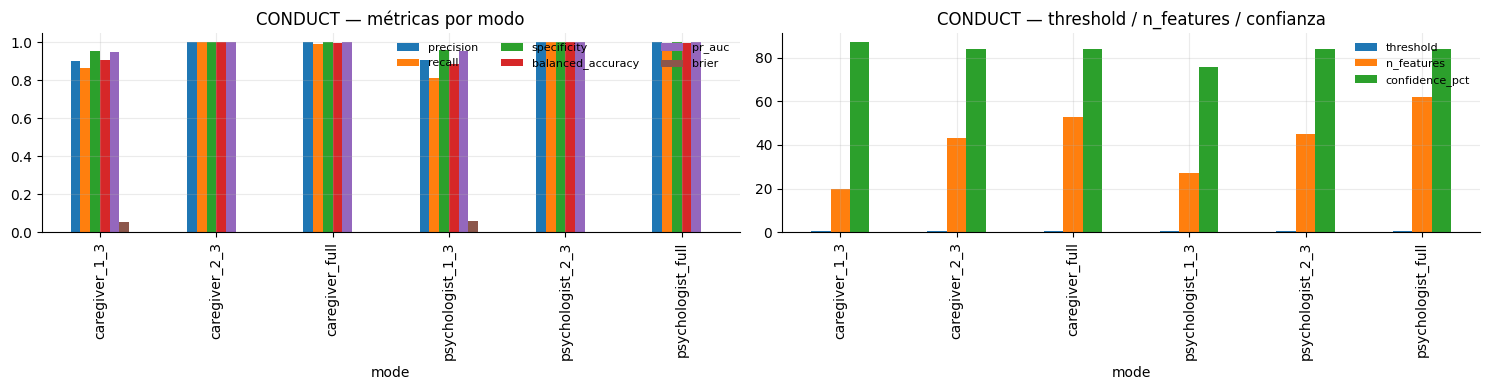

- Mejor BA: **caregiver_2_3** (1.0000)
- Peor BA: **psychologist_1_3** (0.8859)
- Mejor PR-AUC: **caregiver_2_3** (1.0000)
- Modos bajo sospecha de easy dataset: caregiver_2_3, caregiver_full, psychologist_2_3, psychologist_full



### Dominio: DEPRESSION

,mode,model_family,feature_set_id,config_id,seed,n_features,calibration,threshold_policy,threshold,precision,recall,specificity,balanced_accuracy,f1,roc_auc,pr_auc,brier,final_class,final_operational_class,confidence_pct,confidence_band,operational_caveat
18,caregiver_1_3,rf,precision_oriented_subset,rf_baseline,20261101,20,none,recall_constrained,0.5300,0.8060,0.6585,0.9673,0.8129,0.7248,0.9583,0.7648,0.0601,HOLD_FOR_LIMITATION,ACTIVE_LIMITED_USE,18.6000,limited,limited reliability; escalate to richer mode; ...
19,caregiver_2_3,rf,full_eligible,rf_precision_push,20261119,98,isotonic,recall_constrained,0.2150,0.8313,0.8415,0.9648,0.9031,0.8364,0.9574,0.8434,0.0455,HOLD_FOR_LIMITATION,ACTIVE_LIMITED_USE,56.3000,low,limited reliability; escalate to richer mode
20,caregiver_full,catboost,full_eligible,cfg_423b80f215,20270413,127,none,default_0_5,0.5000,0.8409,0.9487,0.9652,0.9569,0.8916,0.9909,0.9435,0.0294,ROBUST_PRIMARY,ACTIVE_HIGH_CONFIDENCE,91.4000,high,boosted override; monitor robustness
21,psychologist_1_3,rf,stability_pruned_subset,rf_baseline,20261101,30,isotonic,default_0_5,0.5000,0.7975,0.7683,0.9598,0.8640,0.7826,0.9484,0.7681,0.0565,HOLD_FOR_LIMITATION,ACTIVE_LIMITED_USE,24.5000,limited,limited reliability; escalate to richer mode; ...
22,psychologist_2_3,rf,full_eligible,rf_pos_weight_mid,20261101,102,isotonic,recall_constrained,0.5050,0.8272,0.8171,0.9648,0.8909,0.8221,0.9557,0.8330,0.0479,HOLD_FOR_LIMITATION,ACTIVE_LIMITED_USE,54.1000,limited,limited reliability; escalate to richer mode
23,psychologist_full,hgb,full_eligible,cfg_06f1522b80,20270413,152,sigmoid,balanced,0.4200,0.8690,0.9359,0.9726,0.9543,0.9012,0.9923,0.9533,0.0253,ROBUST_PRIMARY,ACTIVE_HIGH_CONFIDENCE,92.8000,high,boosted override; monitor robustness


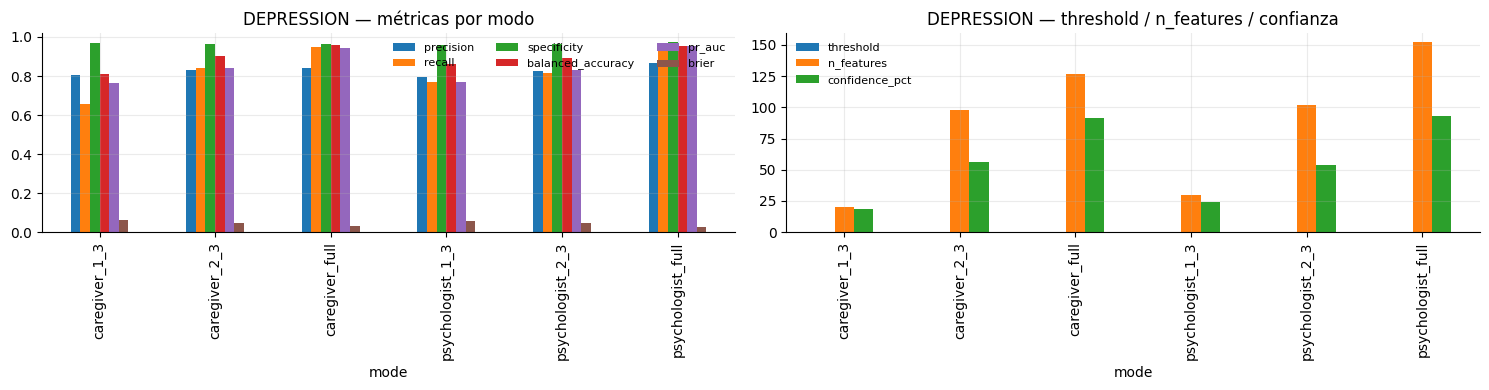

- Mejor BA: **caregiver_full** (0.9569)
- Peor BA: **caregiver_1_3** (0.8129)
- Mejor PR-AUC: **psychologist_full** (0.9533)
- Modos con confianza limitada/baja: caregiver_1_3, caregiver_2_3, psychologist_1_3, psychologist_2_3
- Overrides boosted presentes en: caregiver_full, psychologist_full



### Dominio: ELIMINATION

,mode,model_family,feature_set_id,config_id,seed,n_features,calibration,threshold_policy,threshold,precision,recall,specificity,balanced_accuracy,f1,roc_auc,pr_auc,brier,final_class,final_operational_class,confidence_pct,confidence_band,operational_caveat
24,caregiver_1_3,extra_trees,boosted_eng_full,cfg_ca676b3869,20270413,67,none,balanced,0.4400,0.8679,0.9020,0.9837,0.9428,0.8846,0.9968,0.9700,0.0204,ROBUST_PRIMARY,ACTIVE_HIGH_CONFIDENCE,92.4000,high,boosted override; monitor robustness
25,caregiver_2_3,rf,engineered_compact,rf_recall_guard,20261101,43,isotonic,balanced,0.2050,0.9259,0.9615,0.9907,0.9761,0.9434,0.9971,0.9559,0.0100,ROBUST_PRIMARY,ACTIVE_HIGH_CONFIDENCE,100.0000,high,none
26,caregiver_full,rf,engineered_compact,rf_baseline,20261101,53,isotonic,precision_min_recall,0.5050,0.9615,0.9615,0.9953,0.9784,0.9615,0.9972,0.9583,0.0081,ROBUST_PRIMARY,ACTIVE_HIGH_CONFIDENCE,100.0000,high,none
27,psychologist_1_3,extra_trees,boosted_eng_full,cfg_ca676b3869,20270413,78,none,balanced,0.4300,0.9020,0.9020,0.9883,0.9452,0.9020,0.9966,0.9724,0.0210,ROBUST_PRIMARY,ACTIVE_HIGH_CONFIDENCE,96.9000,high,boosted override; monitor robustness
28,psychologist_2_3,rf,engineered_pruned,rf_recall_guard,20261101,70,isotonic,precision_min_recall,0.5050,0.9615,0.9615,0.9953,0.9784,0.9615,0.9972,0.9577,0.0082,ROBUST_PRIMARY,ACTIVE_HIGH_CONFIDENCE,100.0000,high,none
29,psychologist_full,rf,engineered_compact,rf_baseline,20261101,62,isotonic,precision_min_recall,0.5050,0.9434,0.9615,0.9930,0.9773,0.9524,0.9981,0.9735,0.0091,ROBUST_PRIMARY,ACTIVE_HIGH_CONFIDENCE,100.0000,high,none


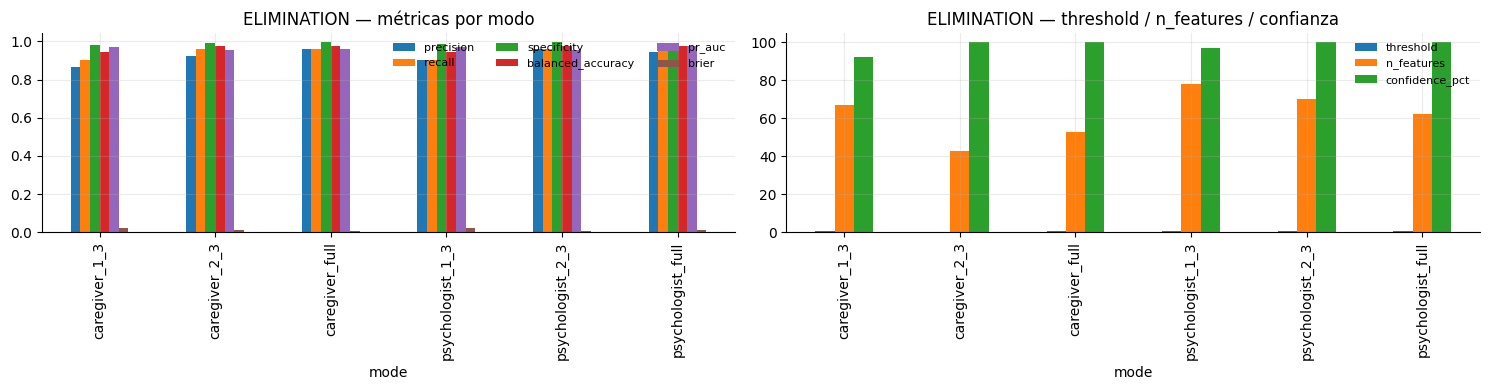

- Mejor BA: **caregiver_full** (0.9784)
- Peor BA: **caregiver_1_3** (0.9428)
- Mejor PR-AUC: **psychologist_full** (0.9735)
- Overrides boosted presentes en: caregiver_1_3, psychologist_1_3



In [26]:

def domain_commentary(sub):
    best_ba = sub.sort_values("balanced_accuracy", ascending=False).iloc[0]
    worst_ba = sub.sort_values("balanced_accuracy", ascending=True).iloc[0]
    best_prauc = sub.sort_values("pr_auc", ascending=False).iloc[0]
    limited = sub[sub["confidence_band"].isin(["limited", "low"])]
    suspect = sub[sub["final_class"].eq("SUSPECT_EASY_DATASET_NEEDS_CAUTION")]
    boosted_here = sub[sub["is_boosted_override"]]
    lines = []
    lines.append(f"- Mejor BA: **{best_ba['mode']}** ({best_ba['balanced_accuracy']:.4f})")
    lines.append(f"- Peor BA: **{worst_ba['mode']}** ({worst_ba['balanced_accuracy']:.4f})")
    lines.append(f"- Mejor PR-AUC: **{best_prauc['mode']}** ({best_prauc['pr_auc']:.4f})")
    if len(limited):
        lines.append("- Modos con confianza limitada/baja: " + ", ".join(limited["mode"].tolist()))
    if len(suspect):
        lines.append("- Modos bajo sospecha de easy dataset: " + ", ".join(suspect["mode"].tolist()))
    if len(boosted_here):
        lines.append("- Overrides boosted presentes en: " + ", ".join(boosted_here["mode"].tolist()))
    return "\n".join(lines)

for domain in sorted(df["domain"].unique()):
    sub = df[df["domain"] == domain].sort_values("mode_order").copy()
    display(Markdown(f"### Dominio: {domain.upper()}"))
    display(sub[[
        "mode", "model_family", "feature_set_id", "config_id", "seed", "n_features",
        "calibration", "threshold_policy", "threshold",
        "precision", "recall", "specificity", "balanced_accuracy", "f1", "roc_auc", "pr_auc", "brier",
        "final_class", "final_operational_class", "confidence_pct", "confidence_band", "operational_caveat"
    ]])

    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
    plot_cols = ["precision", "recall", "specificity", "balanced_accuracy", "pr_auc", "brier"]
    sub.set_index("mode")[plot_cols].plot(kind="bar", ax=axes[0], title=f"{domain.upper()} — métricas por modo")
    axes[0].legend(frameon=False, fontsize=8, ncol=3)

    sub.set_index("mode")[["threshold", "n_features", "confidence_pct"]].plot(kind="bar", ax=axes[1], title=f"{domain.upper()} — threshold / n_features / confianza")
    axes[1].legend(frameon=False, fontsize=8)
    plt.tight_layout()
    plt.show()

    print(domain_commentary(sub))
    print()



## 11. Ranking de outliers y hallazgos tácticos

Esta sección identifica patrones que normalmente interesan mucho en revisión de tesis o comité técnico:

- mejores modelos absolutos,
- peores modelos absolutos,
- modelos “eficientes” (pocas features, buen rendimiento),
- modelos costosos (muchas features) con retorno dudoso,
- thresholds extremos.


In [27]:

best_ba = df.sort_values("balanced_accuracy", ascending=False)[["domain", "mode", "n_features", "balanced_accuracy", "pr_auc", "brier", "final_class"]].head(10)
worst_ba = df.sort_values("balanced_accuracy", ascending=True)[["domain", "mode", "n_features", "balanced_accuracy", "pr_auc", "brier", "final_class"]].head(10)
efficient = df.sort_values(["balanced_accuracy", "n_features"], ascending=[False, True])[["domain", "mode", "n_features", "balanced_accuracy", "pr_auc", "confidence_pct"]].head(10)
feature_heavy = df.sort_values("n_features", ascending=False)[["domain", "mode", "n_features", "balanced_accuracy", "pr_auc", "confidence_pct", "final_class"]].head(10)
threshold_extremes = pd.concat([df.nsmallest(10, "threshold"), df.nlargest(10, "threshold")])[["domain", "mode", "threshold", "precision", "recall", "balanced_accuracy", "threshold_policy"]]

display(Markdown("### Mejores 10 por BA"))
display(best_ba)
display(Markdown("### Peores 10 por BA"))
display(worst_ba)
display(Markdown("### Modelos más eficientes (alta BA con relativamente pocas features)"))
display(efficient)
display(Markdown("### Modelos más cargados en features"))
display(feature_heavy)
display(Markdown("### Thresholds extremos"))
display(threshold_extremes)


### Mejores 10 por BA

,domain,mode,n_features,balanced_accuracy,pr_auc,brier,final_class
16,conduct,psychologist_2_3,45,1.0000,1.0000,0.0011,SUSPECT_EASY_DATASET_NEEDS_CAUTION
13,conduct,caregiver_2_3,43,1.0000,1.0000,0.0013,SUSPECT_EASY_DATASET_NEEDS_CAUTION
17,conduct,psychologist_full,62,0.9969,1.0000,0.0012,SUSPECT_EASY_DATASET_NEEDS_CAUTION
14,conduct,caregiver_full,53,0.9969,1.0000,0.0013,SUSPECT_EASY_DATASET_NEEDS_CAUTION
28,elimination,psychologist_2_3,70,0.9784,0.9577,0.0082,ROBUST_PRIMARY
26,elimination,caregiver_full,53,0.9784,0.9583,0.0081,ROBUST_PRIMARY
29,elimination,psychologist_full,62,0.9773,0.9735,0.0091,ROBUST_PRIMARY
25,elimination,caregiver_2_3,43,0.9761,0.9559,0.0100,ROBUST_PRIMARY
20,depression,caregiver_full,127,0.9569,0.9435,0.0294,ROBUST_PRIMARY
23,depression,psychologist_full,152,0.9543,0.9533,0.0253,ROBUST_PRIMARY


### Peores 10 por BA

,domain,mode,n_features,balanced_accuracy,pr_auc,brier,final_class
18,depression,caregiver_1_3,20,0.8129,0.7648,0.0601,HOLD_FOR_LIMITATION
9,anxiety,psychologist_1_3,69,0.8567,0.9167,0.0356,PRIMARY_WITH_CAVEAT
21,depression,psychologist_1_3,30,0.8640,0.7681,0.0565,HOLD_FOR_LIMITATION
0,adhd,caregiver_1_3,58,0.8714,0.6319,0.0868,HOLD_FOR_LIMITATION
3,adhd,psychologist_1_3,30,0.8741,0.6375,0.0842,HOLD_FOR_LIMITATION
2,adhd,caregiver_full,53,0.8746,0.7119,0.0687,HOLD_FOR_LIMITATION
4,adhd,psychologist_2_3,70,0.8773,0.7337,0.0680,HOLD_FOR_LIMITATION
1,adhd,caregiver_2_3,43,0.8815,0.7044,0.0726,HOLD_FOR_LIMITATION
15,conduct,psychologist_1_3,27,0.8859,0.9543,0.0585,PRIMARY_WITH_CAVEAT
22,depression,psychologist_2_3,102,0.8909,0.8330,0.0479,HOLD_FOR_LIMITATION


### Modelos más eficientes (alta BA con relativamente pocas features)

,domain,mode,n_features,balanced_accuracy,pr_auc,confidence_pct
13,conduct,caregiver_2_3,43,1.0000,1.0000,83.9000
16,conduct,psychologist_2_3,45,1.0000,1.0000,83.9000
14,conduct,caregiver_full,53,0.9969,1.0000,83.9000
17,conduct,psychologist_full,62,0.9969,1.0000,83.9000
26,elimination,caregiver_full,53,0.9784,0.9583,100.0000
28,elimination,psychologist_2_3,70,0.9784,0.9577,100.0000
29,elimination,psychologist_full,62,0.9773,0.9735,100.0000
25,elimination,caregiver_2_3,43,0.9761,0.9559,100.0000
20,depression,caregiver_full,127,0.9569,0.9435,91.4000
23,depression,psychologist_full,152,0.9543,0.9533,92.8000


### Modelos más cargados en features

,domain,mode,n_features,balanced_accuracy,pr_auc,confidence_pct,final_class
5,adhd,psychologist_full,161,0.9124,0.9271,91.7000,ROBUST_PRIMARY
23,depression,psychologist_full,152,0.9543,0.9533,92.8000,ROBUST_PRIMARY
20,depression,caregiver_full,127,0.9569,0.9435,91.4000,ROBUST_PRIMARY
22,depression,psychologist_2_3,102,0.8909,0.8330,54.1000,HOLD_FOR_LIMITATION
19,depression,caregiver_2_3,98,0.9031,0.8434,56.3000,HOLD_FOR_LIMITATION
27,elimination,psychologist_1_3,78,0.9452,0.9724,96.9000,ROBUST_PRIMARY
28,elimination,psychologist_2_3,70,0.9784,0.9577,100.0000,ROBUST_PRIMARY
4,adhd,psychologist_2_3,70,0.8773,0.7337,43.8000,HOLD_FOR_LIMITATION
9,anxiety,psychologist_1_3,69,0.8567,0.9167,73.4000,PRIMARY_WITH_CAVEAT
24,elimination,caregiver_1_3,67,0.9428,0.9700,92.4000,ROBUST_PRIMARY


### Thresholds extremos

,domain,mode,threshold,precision,recall,balanced_accuracy,threshold_policy
3,adhd,psychologist_1_3,0.1800,0.6148,0.8830,0.8741,balanced
25,elimination,caregiver_2_3,0.2050,0.9259,0.9615,0.9761,balanced
19,depression,caregiver_2_3,0.2150,0.8313,0.8415,0.9031,recall_constrained
10,anxiety,psychologist_2_3,0.2300,0.9059,0.8953,0.9375,balanced
8,anxiety,caregiver_full,0.2950,0.9167,0.8953,0.9388,balanced
6,anxiety,caregiver_1_3,0.3200,0.8875,0.8256,0.9014,recall_constrained
7,anxiety,caregiver_2_3,0.3350,0.8736,0.8837,0.9279,balanced
2,adhd,caregiver_full,0.4050,0.7404,0.8191,0.8746,recall_constrained
23,depression,psychologist_full,0.4200,0.8690,0.9359,0.9543,balanced
27,elimination,psychologist_1_3,0.4300,0.9020,0.9020,0.9452,balanced



## 12. Contraste con la línea histórica `reports/final_closure/*`

El repo deja claro que `reports/final_closure/*` es **histórico** y **no** la fuente principal del enfoque dual/híbrido actual.  
Aun así, puede ser útil como contraste para entender la evolución del proyecto.

El objetivo aquí no es mezclar líneas metodológicas como si fueran equivalentes, sino visualizar:

- cómo cambió la lógica de cierre,
- y cómo la línea híbrida activa se volvió mucho más granular por modo y rol.


,domain,final_model_used,final_dataset_used,threshold_final,calibration_strategy,precision,recall,specificity,balanced_accuracy,specificity_reporting_mode,metric_confidence,final_status,current_best_mode,current_model_family,current_balanced_accuracy,current_pr_auc,current_precision,current_recall,current_brier,current_final_class
0,adhd,adhd_trial_compact_signal,processed_hybrid_dsm5_v2,0.7500,not_explicit_in_final_artifacts,0.9797,0.9006,0.9760,0.9383,derived,medium,recovered_generalizing_model,psychologist_full,rf,0.9124,0.9271,0.9294,0.8404,0.0302,ROBUST_PRIMARY
1,anxiety,retrained_anxiety_anti_overfit_v1,processed_hybrid_dsm5_v2,0.0500,not_explicit_in_final_metrics_csv,0.9701,0.9848,0.9909,0.9879,derived,medium,accepted_but_experimental,caregiver_full,rf,0.9388,0.9465,0.9167,0.8953,0.0274,ROBUST_PRIMARY
2,conduct,domain_conduct_research_full,processed_hybrid_dsm5_v2,0.7000,not_explicit_in_final_metrics_csv,0.9753,0.9875,0.9903,0.9889,derived,medium,accepted_but_experimental,caregiver_2_3,rf,1.0000,1.0000,1.0000,1.0000,0.0013,SUSPECT_EASY_DATASET_NEEDS_CAUTION
3,depression,domain_depression_strict_full,processed_hybrid_dsm5_v2,0.7500,not_explicit_in_final_metrics_csv,0.9739,0.9739,0.9825,0.9782,derived,medium,accepted_but_experimental,caregiver_full,catboost,0.9569,0.9435,0.8409,0.9487,0.0294,ROBUST_PRIMARY
4,elimination,V5_T02_composite_clinical,processed_hybrid_dsm5_v2,0.5000,none,0.9437,0.9379,0.9280,0.9329,direct,high,experimental_line_more_useful_not_product_ready,caregiver_full,rf,0.9784,0.9583,0.9615,0.9615,0.0081,ROBUST_PRIMARY


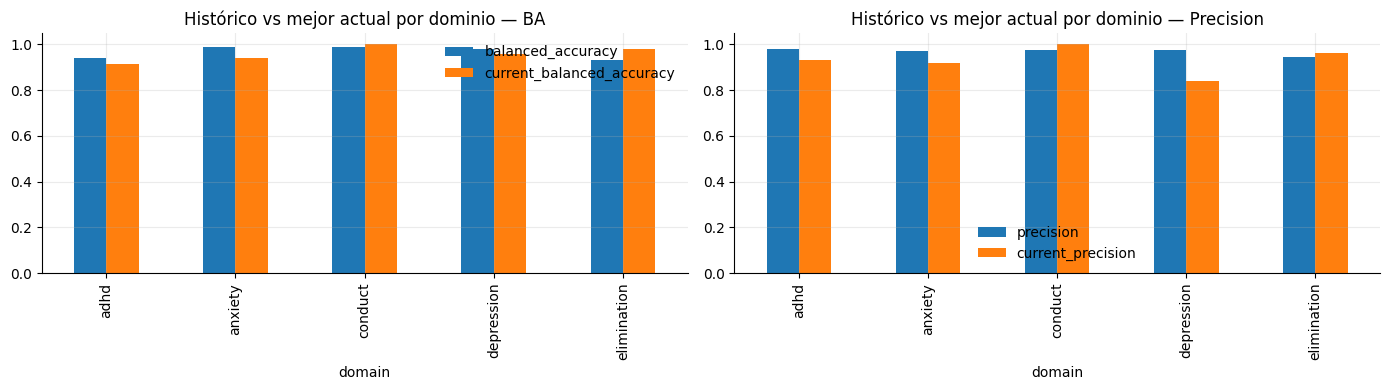

In [28]:

current_best_by_domain = (
    df.sort_values(["domain", "balanced_accuracy"], ascending=[True, False])
      .groupby("domain")
      .head(1)
      [["domain", "mode", "model_family", "balanced_accuracy", "pr_auc", "precision", "recall", "brier", "final_class"]]
      .rename(columns={
          "mode": "current_best_mode",
          "model_family": "current_model_family",
          "balanced_accuracy": "current_balanced_accuracy",
          "pr_auc": "current_pr_auc",
          "precision": "current_precision",
          "recall": "current_recall",
          "brier": "current_brier",
          "final_class": "current_final_class",
      })
)

historical_compare = historical_final.merge(current_best_by_domain, on="domain", how="left")
display(historical_compare)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
historical_compare.set_index("domain")[["balanced_accuracy", "current_balanced_accuracy"]].plot(kind="bar", ax=axes[0], title="Histórico vs mejor actual por dominio — BA")
historical_compare.set_index("domain")[["precision", "current_precision"]].plot(kind="bar", ax=axes[1], title="Histórico vs mejor actual por dominio — Precision")
for ax in axes:
    ax.legend(frameon=False)
plt.tight_layout()
plt.show()



## 13. Inputs / complejidad operacional de la línea activa

Según la trazabilidad del repo, la activación final usa un contrato de inputs con:

- **203 inputs** en el maestro de cuestionario,
- **152 directos**,
- **51 transparent derived**,
- **51 que requieren internal scoring**.

Esto importa porque los 30 modelos no existen aislados: dependen de un runtime y un contrato de inputs que debe seguir siendo consistente.


,value
questionnaire_inputs_master_rows,203
direct_inputs,152
transparent_derived,51
requires_internal_scoring,51


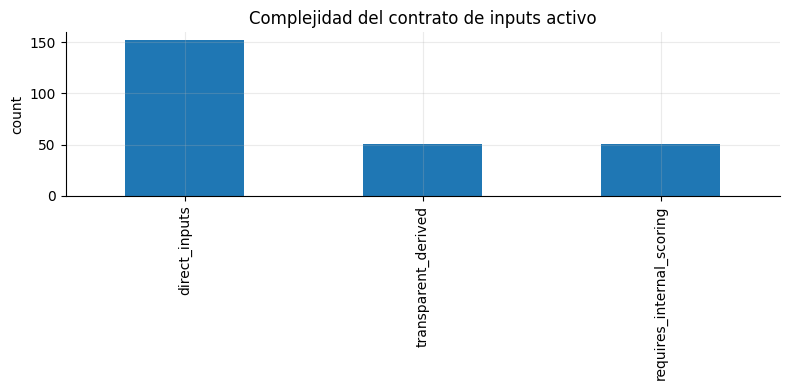

In [29]:

display(pd.DataFrame([input_contract_snapshot]).T.rename(columns={0: "value"}))

fig, ax = plt.subplots(figsize=(8, 4))
pd.Series({
    "direct_inputs": input_contract_snapshot["direct_inputs"],
    "transparent_derived": input_contract_snapshot["transparent_derived"],
    "requires_internal_scoring": input_contract_snapshot["requires_internal_scoring"],
}).plot(kind="bar", ax=ax)
ax.set_title("Complejidad del contrato de inputs activo")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()



## 14. Conclusiones automáticas generadas desde los datos

La siguiente celda produce un resumen textual **basado en los datos cargados**.  
Sirve como borrador técnico para incluir luego en documento de tesis, informe de comité o cierre metodológico.


In [30]:

best_portfolio = df.sort_values("balanced_accuracy", ascending=False).iloc[0]
worst_portfolio = df.sort_values("balanced_accuracy", ascending=True).iloc[0]
full_mean = df.groupby("mode_depth")["balanced_accuracy"].mean().reindex(["1/3", "2/3", "full"])
role_mean = df.groupby("role")["balanced_accuracy"].mean()
domain_rank = df.groupby("domain")["balanced_accuracy"].mean().sort_values(ascending=False)
risk_domains = df.groupby("domain").apply(lambda g: (g["final_class"] == "HOLD_FOR_LIMITATION").sum()).sort_values(ascending=False)

text = f'''
### Resumen ejecutivo automático

- El portfolio final contiene **{len(df)} modelos activos**, con cobertura completa de **{df["domain"].nunique()} dominios × {df["mode"].nunique()} modos**.
- La clase final se distribuye en:
  - **ROBUST_PRIMARY = {(df["final_class"] == "ROBUST_PRIMARY").sum()}**
  - **PRIMARY_WITH_CAVEAT = {(df["final_class"] == "PRIMARY_WITH_CAVEAT").sum()}**
  - **HOLD_FOR_LIMITATION = {(df["final_class"] == "HOLD_FOR_LIMITATION").sum()}**
  - **SUSPECT_EASY_DATASET_NEEDS_CAUTION = {(df["final_class"] == "SUSPECT_EASY_DATASET_NEEDS_CAUTION").sum()}**
- La activación operativa muestra:
  - **ACTIVE_HIGH_CONFIDENCE = {(df["final_operational_class"] == "ACTIVE_HIGH_CONFIDENCE").sum()}**
  - **ACTIVE_MODERATE_CONFIDENCE = {(df["final_operational_class"] == "ACTIVE_MODERATE_CONFIDENCE").sum()}**
  - **ACTIVE_LIMITED_USE = {(df["final_operational_class"] == "ACTIVE_LIMITED_USE").sum()}**

#### Hallazgos cuantitativos más fuertes
- Mejor modelo del portfolio por BA:
  - **{best_portfolio["domain"]} | {best_portfolio["mode"]}**
  - BA = **{best_portfolio["balanced_accuracy"]:.4f}**
  - PR-AUC = **{best_portfolio["pr_auc"]:.4f}**
  - Clase final = **{best_portfolio["final_class"]}**

- Modelo más débil por BA:
  - **{worst_portfolio["domain"]} | {worst_portfolio["mode"]}**
  - BA = **{worst_portfolio["balanced_accuracy"]:.4f}**
  - PR-AUC = **{worst_portfolio["pr_auc"]:.4f}**
  - Clase final = **{worst_portfolio["final_class"]}**

#### Lectura de profundidad del cuestionario
- BA promedio en modos 1/3 = **{full_mean["1/3"]:.4f}**
- BA promedio en modos 2/3 = **{full_mean["2/3"]:.4f}**
- BA promedio en modos full = **{full_mean["full"]:.4f}**

Interpretación: el modo **full** sí muestra la señal promedio más fuerte del portfolio, pero el beneficio **no** es uniforme en todos los dominios. En ADHD y Depression la diferencia entre modos sigue siendo crítica; en Conduct algunos resultados son tan altos que requieren cautela por posible facilidad del dataset.

#### Lectura por rol
- BA promedio caregiver = **{role_mean["caregiver"]:.4f}**
- BA promedio psychologist = **{role_mean["psychologist"]:.4f}**

#### Ranking promedio por dominio (BA media)
{domain_rank.to_string()}

#### Dominios con más pares en HOLD_FOR_LIMITATION
{risk_domains.to_string()}

#### Interpretación metodológica
- **Anxiety** y **Elimination** muestran portfolios muy sólidos en la línea final activa.
- **Conduct** aparece extremadamente fuerte en varios modos, pero con señal explícita de **possible easy-dataset inflation** en 4 pares.
- **ADHD** no quedó homogéneamente fuerte: el dominio se rescata principalmente por **psychologist_full**; los modos cortos siguen limitados.
- **Depression** conserva una fractura clara entre modos cortos limitados y overrides boosted full que sí levantan la frontera.
- La historia del repo respalda que la decisión correcta no fue seguir iterando masivamente RF, sino pasar a:
  1. línea limpia sin scores externos,
  2. boosting focalizado donde había retorno,
  3. activación total 30/30 con caveats explícitos.
'''
display(Markdown(text))


C:\Users\andre\AppData\Local\Temp\ipykernel_4024\685294457.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  risk_domains = df.groupby("domain").apply(lambda g: (g["final_class"] == "HOLD_FOR_LIMITATION").sum()).sort_values(ascending=False)



### Resumen ejecutivo automático

- El portfolio final contiene **30 modelos activos**, con cobertura completa de **5 dominios × 6 modos**.
- La clase final se distribuye en:
  - **ROBUST_PRIMARY = 15**
  - **PRIMARY_WITH_CAVEAT = 2**
  - **HOLD_FOR_LIMITATION = 9**
  - **SUSPECT_EASY_DATASET_NEEDS_CAUTION = 4**
- La activación operativa muestra:
  - **ACTIVE_HIGH_CONFIDENCE = 15**
  - **ACTIVE_MODERATE_CONFIDENCE = 6**
  - **ACTIVE_LIMITED_USE = 9**

#### Hallazgos cuantitativos más fuertes
- Mejor modelo del portfolio por BA:
  - **conduct | psychologist_2_3**
  - BA = **1.0000**
  - PR-AUC = **1.0000**
  - Clase final = **SUSPECT_EASY_DATASET_NEEDS_CAUTION**

- Modelo más débil por BA:
  - **depression | caregiver_1_3**
  - BA = **0.8129**
  - PR-AUC = **0.7648**
  - Clase final = **HOLD_FOR_LIMITATION**

#### Lectura de profundidad del cuestionario
- BA promedio en modos 1/3 = **0.8862**
- BA promedio en modos 2/3 = **0.9373**
- BA promedio en modos full = **0.9519**

Interpretación: el modo **full** sí muestra la señal promedio más fuerte del portfolio, pero el beneficio **no** es uniforme en todos los dominios. En ADHD y Depression la diferencia entre modos sigue siendo crítica; en Conduct algunos resultados son tan altos que requieren cautela por posible facilidad del dataset.

#### Lectura por rol
- BA promedio caregiver = **0.9247**
- BA promedio psychologist = **0.9256**

#### Ranking promedio por dominio (BA media)
domain
elimination   0.9664
conduct       0.9646
anxiety       0.9159
depression    0.8970
adhd          0.8819

#### Dominios con más pares en HOLD_FOR_LIMITATION
domain
adhd           5
depression     4
anxiety        0
conduct        0
elimination    0

#### Interpretación metodológica
- **Anxiety** y **Elimination** muestran portfolios muy sólidos en la línea final activa.
- **Conduct** aparece extremadamente fuerte en varios modos, pero con señal explícita de **possible easy-dataset inflation** en 4 pares.
- **ADHD** no quedó homogéneamente fuerte: el dominio se rescata principalmente por **psychologist_full**; los modos cortos siguen limitados.
- **Depression** conserva una fractura clara entre modos cortos limitados y overrides boosted full que sí levantan la frontera.
- La historia del repo respalda que la decisión correcta no fue seguir iterando masivamente RF, sino pasar a:
  1. línea limpia sin scores externos,
  2. boosting focalizado donde había retorno,
  3. activación total 30/30 con caveats explícitos.



## 15. Recomendaciones de uso de este notebook

### Úsalo para
- capítulo de resultados de tesis,
- apéndice técnico de trazabilidad,
- soporte para defensa metodológica,
- revisión rápida de cuáles modos son confiables y cuáles no,
- conversación entre runtime/API/modeling sin perder consistencia.

### No lo uses para
- vender el sistema como diagnóstico clínico automático,
- colapsar todos los dominios y modos en un único número global,
- ignorar caveats de confianza, facilidad de dataset u overfitting,
- presentar como equivalentes la línea histórica `final_closure` y la línea híbrida activa actual.
